In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from utils import decorate, underride, configure_plot_style, AIBM_COLORS, code_to_who_country, code_to_wef_country, write_html_table

configure_plot_style()

In [3]:
def load_and_inventory(filename):
    """
    Load a WHO health indicator CSV file and print inventory information.
    
    Filters the data to include only records from year 2000 to 2019 (excludes 2020+)
    to avoid COVID-19 pandemic distortions, and country-level data (excludes regional aggregates).
    Adds a 'Country' column mapping country codes to country names using code_to_who_country.
    
    Parameters
    ----------
    filename : str
        Path to the CSV file containing WHO health indicator data.
        
    Returns
    -------
    df : pandas.DataFrame
        Filtered DataFrame containing country-level data from 2000-2019,
        with an additional 'Country' column.
    years : numpy.ndarray
        Array of unique years present in the filtered dataset.
    """
    # Filter to 2000-2019 to exclude COVID-19 pandemic years (2020+)
    df = pd.read_csv(filename).query('Year >= 2000 and Year <= 2019 and CountryCode == "COUNTRY"')
    
    # Add country name column using code_to_who_country mapping
    # The 'Country' column contains country codes (e.g., 'USA', 'GBR')
    # Rename 'Country' (codes) to 'Code', then add 'Country' (names)
    df = df.rename(columns={'Country': 'Code'})
    df['Country'] = df['Code'].map(code_to_who_country)
    
    print(df.shape)

    try:
        print(df['IndicatorCode'].unique())
        print(df['IndicatorName'].unique())
    except KeyError:
        pass

    sexes = df['Sex'].unique()
    print(sexes)
    print(df['Comments'].unique())
    years = df['Year'].unique()
    print(years)
    print(df['Country'].unique())
    
    return df, years

In [4]:
from functools import reduce

def compute_gender_gap(df, value_col, sexes):
    """
    Return a DataFrame with separate columns for each sex, a gap column, and a midpoint column,
    handling cases where one or more sexes are missing.

    Parameters
    ----------
    df : pandas.DataFrame
        Must include 'Code' (country codes), 'Year', 'Sex', and the specified value_col.
        May also include 'Country' (country names) which will be preserved.
    value_col : str
        Name of the column containing the numeric value to compare between sexes.
    sexes : list of str
        List of values in the 'Sex' column, e.g. ['SEX_MLE', 'SEX_FMLE'].
        The first two entries are used to compute the gap (first - second) and midpoint (average).

    Returns
    -------
    df_by_sex : pandas.DataFrame
        Contains columns for each available sex, a gap column (Gap_{value_col} = first - second, i.e., Male - Female),
        and a midpoint column (Mid_{value_col} = average of first and second) if both sexes
        are present. Also includes 'Country' (added via mapping) and 'Year'.
    """
    # Determine which columns to keep
    # Base columns: Code (country codes), Year, and the value column (which will be renamed)
    # Country (country names) will be added later via mapping
    base_cols = ['Code', 'Year']
    
    dfs = []

    # Build a renamed DataFrame for each sex, only if it exists
    # Select only the columns we want to keep before merging
    for sex in sexes:
        temp = df[df['Sex'] == sex]
        if not temp.empty:
            # Select only the columns we need: base columns + value column
            cols_to_select = base_cols + [value_col]
            temp = temp[cols_to_select].copy()
            # Rename the value column to include the sex
            temp = temp.rename(columns={value_col: f"{value_col}_{sex}"})
            dfs.append(temp)

    # If no data at all, return empty DataFrame
    if not dfs:
        return pd.DataFrame(columns=['Code', 'Year'])

    # Merge all available sexes
    merge_on = ['Code', 'Year']
    df_by_sex = reduce(lambda left, right: left.merge(right, on=merge_on, how='outer'), dfs)

    # Compute the gap and midpoint only if both sexes are available
    # Gap = Male - Female (first - second, where first is typically Male)
    if len(sexes) >= 2:
        col1 = f"{value_col}_{sexes[0]}"
        col2 = f"{value_col}_{sexes[1]}"
        if col1 in df_by_sex.columns and col2 in df_by_sex.columns:
            df_by_sex[f"Gap_{value_col}"] = df_by_sex[col1] - df_by_sex[col2]
            df_by_sex[f"Mid_{value_col}"] = (df_by_sex[col1] + df_by_sex[col2]) / 2

    df_by_sex['Country'] = df_by_sex['Code'].map(code_to_who_country)

    return df_by_sex


In [5]:
def summarize_gap(df, col, sexes=None):
    """
    Compute gender gap and create summary visualization using most recent data per country.
    
    Computes gender gaps using compute_gender_gap, then selects the most recent year
    available for each country (which may differ by country). Creates a scatter plot
    comparing values between sexes (if multiple sexes are provided) for OECD countries only.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing health indicator data with 'Code' (country codes), 'Year', 'Sex',
        and the value column specified by col. May also include 'Country' (country names).
    col : str
        Name of the column containing the numeric value to compare between sexes.
    sexes : list of str
        List of sex values to compare (e.g., ['Male', 'Female']).
        
    Returns
    -------
    df_gap : pandas.DataFrame
        DataFrame with gender gap computed for all years. Includes 'Country' and 'Year' columns.
    df_recent : pandas.DataFrame
        DataFrame with the most recent available year for each country, indexed by Code.
        Includes 'Country' and 'Year' columns. Returns all countries, not just OECD.
    """
    sexes = sexes or ['Male', 'Female']
    df_gap = compute_gender_gap(df, col, sexes)
    
    # Get the most recent year for each country
    most_recent_years = df_gap.groupby('Code')['Year'].max().reset_index()
    df_recent = df_gap.merge(most_recent_years, on=['Code', 'Year'])
    
    # Set index to Code, but keep Country and Year as columns
    df_recent = df_recent.set_index('Code')
    
    if len(sexes) > 1:
        cols = [f'{col}_{sex}' for sex in sexes]
        # Get OECD countries for plotting
        df_recent_oecd = get_oecd(df_recent)
        high = df_recent_oecd[cols].max().max()
        domain = [0, high]
        scatter_plot(df_recent_oecd, cols, domain)
        decorate(xlabel=f'{col}, Male', 
                 ylabel=f'{col}, Female', title=f'OECD Countries')
    
    return df_gap, df_recent

In [6]:
def scatter_plot(df, cols, domain, **options):
    """
    Create a scatter plot comparing two columns with a diagonal reference line.
    
    Plots the values from two columns against each other, with a diagonal
    reference line (y=x) to show equality. Uses a square aspect ratio by default.
    Labels specific countries: USA, DEU, LTU, NDL.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by country, containing the columns to plot.
    cols : list of str
        List of two column names to plot on x and y axes.
    domain : list of float
        Two-element list [min, max] defining the plot domain for both axes.
    **options : dict
        Additional keyword arguments passed to decorate() for plot customization
        (e.g., xlabel, ylabel, title).
    """
    plt.plot(df[cols[0]], df[cols[1]], '.', color=AIBM_COLORS['crimson'])
    plt.plot(domain, domain, color='gray', alpha=0.5)
    
    # Label specific countries
    countries_to_label = ['USA', 'DEU', 'LTU', 'NLD']
    for country in countries_to_label:
        if country in df.index:
            x_val = df.loc[country, cols[0]]
            y_val = df.loc[country, cols[1]]
            if pd.notna(x_val) and pd.notna(y_val):
                plt.annotate(country, (x_val, y_val), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=9, alpha=0.8)
    
    underride(options, aspect='equal')
    decorate(**options)

In [7]:
from utils import oecd_codes
import warnings

def get_oecd(df):
    """
    Filter DataFrame to include only OECD member countries.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by country codes.
        
    Returns
    -------
    pandas.DataFrame
        Subset of the input DataFrame containing only OECD countries.
        
    Note
    -----
    Warns if any expected OECD countries are missing from the data.
    """
    available_countries = set(df.index)
    expected_oecd = set(oecd_codes)
    missing_countries = expected_oecd - available_countries
    
    if missing_countries:
        warnings.warn(
            f"Missing {len(missing_countries)} OECD countries in data: {sorted(missing_countries)}",
            UserWarning
        )
    
    return df.loc[df.index.intersection(oecd_codes)]

In [8]:
def summarize_years(predictor_dfs):
    """
    Create a summary table of year coverage for each indicator in predictor_dfs.
    
    Parameters
    ----------
    predictor_dfs : dict
        Dictionary mapping indicator names to DataFrames containing predictor data.
        Each DataFrame should have a 'Year' column.
        
    Returns
    -------
    pandas.DataFrame
        Summary table with columns: Indicator, Low_Year, High_Year, Most_Common_Year,
        N_Countries_Most_Common, Total_Countries.
    """
    year_summary = []
    
    for name, df in predictor_dfs.items():
        years = df['Year'].dropna()
        if len(years) > 0:
            year_counts = years.value_counts()
            most_common_year = year_counts.index[0]
            n_countries_most_common = year_counts.iloc[0]
            
            year_summary.append({
                'Indicator': name,
                'Low_Year': int(years.min()),
                'High_Year': int(years.max()),
                'Most_Common_Year': int(most_common_year),
                'N_Countries_Most_Common': int(n_countries_most_common),
                'Total_Countries': len(df)
            })
        else:
            year_summary.append({
                'Indicator': name,
                'Low_Year': np.nan,
                'High_Year': np.nan,
                'Most_Common_Year': np.nan,
                'N_Countries_Most_Common': 0,
                'Total_Countries': len(df)
            })
            
    return pd.DataFrame(year_summary)

In [9]:
from empiricaldist import Cdf

def plot_cdfs(df, label='', **options):
    """
    Plot cumulative distribution functions (CDFs) for columns ending in 'ale'.
    
    Creates CDF plots for all columns in the DataFrame that end with 'ale'
    (typically 'Male' and 'Female' columns). Each CDF is plotted with a label
    combining the column name and the provided label.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing numeric columns to plot as CDFs.
    label : str, optional
        Additional label text to append to each CDF plot label (default: '').
    **options : dict
        Additional keyword arguments for plot customization.
    """
    cols = [col for col in df.columns if col.endswith('ale')]
    for col in cols:
        vals = df[col].dropna()
        if vals.count() == 0:
            break
        cdf = Cdf.from_seq(df[col])
        cdf.plot(label=f'{col} {label}', **options)

In [10]:
def plot_distributions(recent, **options):
    """
    Plot CDFs comparing all countries vs OECD countries.
    
    Creates cumulative distribution function plots for both all countries
    and OECD countries subset, allowing comparison of distributions.
    
    Parameters
    ----------
    recent : pandas.DataFrame
        DataFrame indexed by country codes, containing columns ending in 'ale'
        (typically 'Male' and 'Female' columns).
    **options : dict
        Additional keyword arguments passed to decorate() for plot customization
        (e.g., xlabel, title). The ylabel is automatically set to 'CDF'.
    """
    plot_cdfs(recent, label='All countries')
    plot_cdfs(get_oecd(recent), label='OECD')
    
    # Extract indicator name from column names (remove _Male or _Female suffix)
    cols = [col for col in recent.columns if col.endswith('ale')]
    if cols:
        # Get the first column and extract the indicator name
        first_col = cols[0]
        # Remove _Male or _Female suffix to get the indicator name
        indicator_name = first_col.rsplit('_')[:-1] if '_' in first_col else first_col
        xlabel = indicator_name
    else:
        xlabel = ''
    
    underride(options, xlabel=xlabel, ylabel='CDF')
    decorate(**options)

In [11]:
# Map from original value column names to short indicator names
# Used to rename columns before computing gaps so Gap_ and Mid_ columns use short names
column_name_mapping = {
    'CardioDeathRate': 'Cardiovascular',
    'ChronicRespiratoryDeathRate': 'ChronicRespiratory',
    'SuicideRate': 'Suicide',
    'AlcoholDeathRate': 'Alcohol',
    'PoisoningRate': 'Poisoning',
    'RoadTrafficDeathRate': 'RoadTraffic',
    'HomicideRate': 'Homicide',
    'MaternalMortalityRatio': 'MaternalMortality',
    'U5MR': 'Childhood',
    'DiabetesDeathRate': 'Diabetes',
    'DrugDisorderDeathRate': 'DrugDisorder',
    'UnintentionalInjuriesDeathRate': 'UnintentionalInjury',
    'NeoplasmsDeathRate': 'Neoplasms',
    'AlcoholUseDisordersDeathRate': 'AlcoholUseDisorders',
    'SelfHarmDeathRate': 'SelfHarm',
    'InterpersonalViolenceDeathRate': 'InterpersonalViolence',
    'RoadInjuriesDeathRate': 'RoadInjuries',
    'MaternalDisordersDeathRate': 'MaternalDisorders',
    'AllCausesUnder5DeathRate': 'AllCausesUnder5',
}

## WHO HALE data

**Healthy Life Expectancy (HALE) at birth** - The average number of years that a person can expect to live in "full health" by taking into account years lived in less than full health due to disease and/or injury. This is the **target variable** for the analysis. The gender gap (Male HALE - Female HALE) measures the difference in healthy life expectancy between men and women.

**Indicator Code**: WHOSIS_000002  
**Relevance**: Direct measure of the outcome we're trying to explain. Gender differences in HALE reflect the cumulative impact of all mortality and morbidity factors that differentially affect men and women.

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [12]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename)

(11100, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece'
 'Grenada' 'Guatemala' 'Guyana' 'Honduras

In [13]:
d = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male', }
hale['Sex'] = hale['Sex'].replace(d)

In [14]:
hale.head()

,Code,CountryCode,Year,Sex,HALE_Years,HALE_Low,HALE_High,Comments,DataSource,Country
0,AFG,COUNTRY,2000,Both,46.027950,44.939602,47.308578,NaN,NaN,Afghanistan
1,AFG,COUNTRY,2001,Both,46.116121,44.907570,47.033098,NaN,NaN,Afghanistan
2,AFG,COUNTRY,2002,Both,47.184852,46.147952,48.308520,NaN,NaN,Afghanistan
3,AFG,COUNTRY,2003,Both,47.977953,47.016452,48.976006,NaN,NaN,Afghanistan
4,AFG,COUNTRY,2004,Both,48.324761,47.311935,49.325042,NaN,NaN,Afghanistan


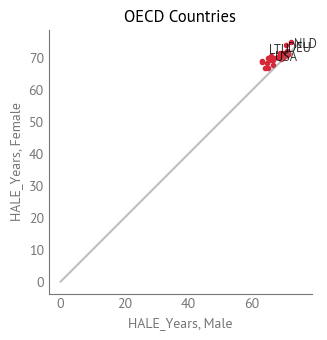

In [15]:
col = 'HALE_Years'
year = years[-1]
hale_gap, hale_recent = summarize_gap(hale, col)

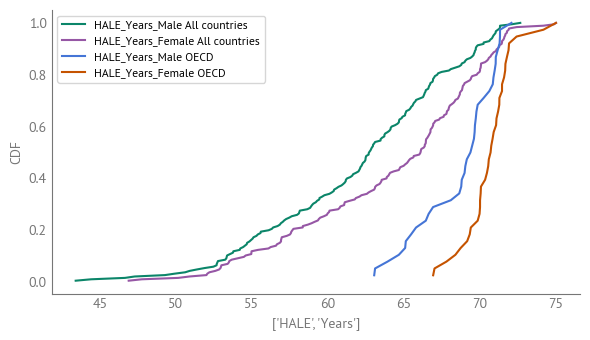

In [16]:
plot_distributions(hale_recent)

## WHO Life Expectancy data

**Life Expectancy at birth** - The average number of years that a person can expect to live, regardless of health status. This is the **secondary target variable** for the analysis, allowing comparison of which factors explain the gender gap in overall life expectancy versus healthy life expectancy. The gender gap (Female LE - Male LE) measures the difference in life expectancy between women and men.

**Indicator Code**: WHOSIS_000001  
**Relevance**: Life expectancy captures all years lived (healthy and unhealthy), while HALE focuses on healthy years only. Both are calculated from birth, so both should be affected by the same mortality patterns. The relative importance of early-life vs adult mortality may differ between the two outcomes.

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [17]:
filename = '../data/who_life_expectancy_data.csv'
le, years = load_and_inventory(filename)

(11100, 10)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece'
 'Grenada' 'Guatemala' 'Guyana' 'Honduras' '

In [18]:
d = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male', }
le['Sex'] = le['Sex'].replace(d)

In [19]:
le.head()

,Code,CountryCode,Year,Sex,LifeExpectancy_Years,LifeExpectancy_Low,LifeExpectancy_High,Comments,DataSource,Country
0,AFG,COUNTRY,2000,Both sexes,53.823326,52.751923,54.926015,NaN,NaN,Afghanistan
1,AFG,COUNTRY,2001,Both sexes,53.910188,52.857250,54.846553,NaN,NaN,Afghanistan
2,AFG,COUNTRY,2002,Both sexes,55.154478,54.078547,56.222277,NaN,NaN,Afghanistan
3,AFG,COUNTRY,2003,Both sexes,56.085207,55.068934,57.034609,NaN,NaN,Afghanistan
4,AFG,COUNTRY,2004,Both sexes,56.476521,55.550402,57.201137,NaN,NaN,Afghanistan


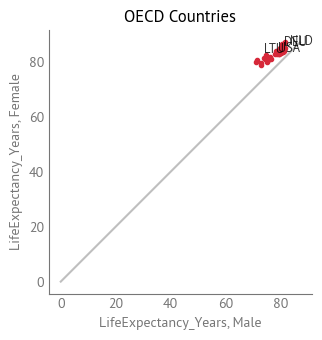

In [20]:
col = 'LifeExpectancy_Years'
year = years[-1]
le_gap, le_recent = summarize_gap(le, col)

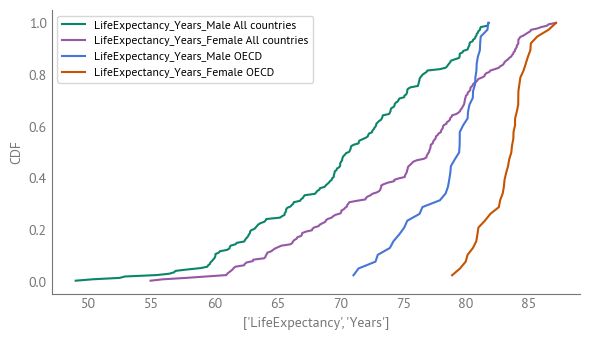

In [21]:
plot_distributions(le_recent)

## Smoking

**Age-standardized current tobacco smoking prevalence (%)** - Percentage of population aged 15+ who currently smoke any tobacco product, age-standardized for cross-country comparison.

**Indicator Code**: M_Est_smk_curr_std  
**Relevance**: Historically, men have had significantly higher smoking rates than women. Smoking is a major contributor to cardiovascular disease, lung cancer, and respiratory diseases. As smoking rates have converged between genders in some countries, the life expectancy gap has narrowed, suggesting smoking is one of the most important modifiable factors contributing to the HALE gender gap.

In [22]:
filename = '../data/who_smoking_data.csv'
smoking, years = load_and_inventory(filename)

(2475, 12)
['M_Est_smk_curr_std']
['Age-standardized current tobacco smoking prevalence']
['Both sexes' 'Female' 'Male']
[nan 'The most recent survey was conducted in 2013. This is a projection.'
 'The most recent survey was conducted in 2011-12. This is a projection.'
 'The most recent survey was conducted in 2012. This is a projection.'
 'The most recent survey was conducted in 2014. This is a projection.']
[2000 2005 2007 2010 2015]
['Afghanistan' 'Albania' 'Andorra' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Burundi' 'Belgium' 'Benin'
 'Burkina Faso' 'Bangladesh' 'Bulgaria' 'Bahrain' 'Bahamas'
 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia' 'Brazil' 'Barbados'
 'Brunei' 'Bhutan' 'Botswana' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Cook Islands' 'Colombia'
 'Comoros' 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Spain'


In [23]:
smoking.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,SmokingPrevalence,SmokingPrevalence_Low,SmokingPrevalence_High,Comments,DataSource,Country
0,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2000,Both sexes,22.5,10.5,34.4,NaN,NaN,Afghanistan
1,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2005,Both sexes,17.9,9.6,26.3,NaN,NaN,Afghanistan
2,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2007,Both sexes,16.3,9.4,23.3,NaN,NaN,Afghanistan
3,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2010,Both sexes,14.5,9.6,19.4,NaN,NaN,Afghanistan
4,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2015,Both sexes,11.8,8.0,15.6,NaN,NaN,Afghanistan


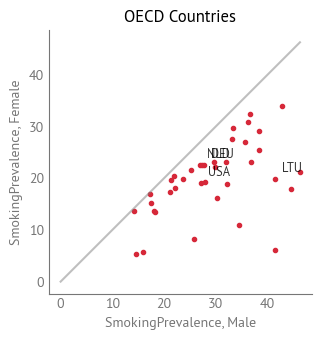

In [24]:
col = 'SmokingPrevalence'
year = years[-1]
smoking_gap, smoking_recent = summarize_gap(smoking, col)

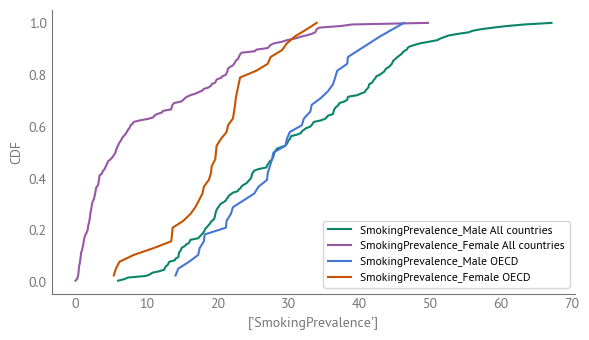

In [25]:
plot_distributions(smoking_recent)

## Suicide

**Age-standardized suicide rates (per 100,000 population)** - Deaths from intentional self-harm, age-standardized for cross-country comparison.

**Indicator Code**: MH_12  
**Relevance**: Suicide rates are typically higher in men across most countries, directly contributing to the gender gap in mortality. Suicide reflects mental health and social factors that differentially affect men and women, and is strongly linked to mortality.

In [26]:
filename = '../data/who_suicide_rates.csv'
suicide, years = load_and_inventory(filename)

(11100, 12)
['MH_12']
['Age-standardized suicide rates (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Eq

In [27]:
suicide.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,SuicideRate,SuicideRate_Low,SuicideRate_High,Comments,DataSource,Country
0,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2000,Both sexes,7.185717,3.764944,12.084243,NaN,NaN,Afghanistan
1,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2001,Both sexes,7.270323,3.817979,12.215665,NaN,NaN,Afghanistan
2,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2002,Both sexes,7.112670,3.821785,11.814730,NaN,NaN,Afghanistan
3,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2003,Both sexes,7.043811,3.856506,12.002093,NaN,NaN,Afghanistan
4,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2004,Both sexes,7.025987,3.889151,12.129586,NaN,NaN,Afghanistan


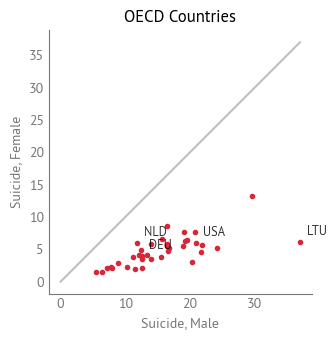

In [28]:
col = 'SuicideRate'
suicide = suicide.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
suicide_gap, suicide_recent = summarize_gap(suicide, col)

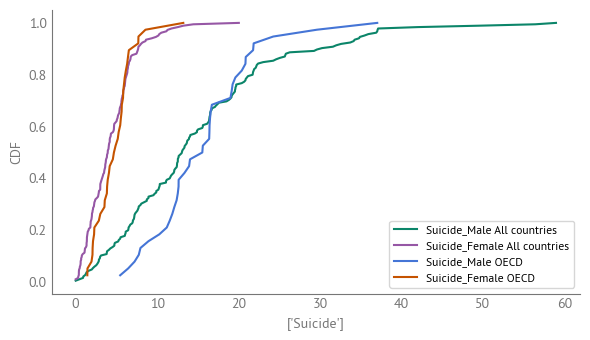

In [29]:
plot_distributions(suicide_recent)

## Alcohol

**Alcohol-attributable all-cause deaths per 100,000 (age-standardized)** - Deaths from all causes that are attributable to alcohol consumption, including direct alcohol-related deaths and alcohol-attributable deaths from other causes (e.g., accidents, liver disease).

**Indicator Code**: SA_0000001832  
**Relevance**: Men typically have higher rates of alcohol consumption and alcohol-related diseases. Alcohol contributes to liver disease, accidents, and various health conditions, directly impacting mortality. Age-standardized rates match HALE methodology for cross-country comparison.

In [30]:
filename = '../data/who_alcohol_death_rates.csv'
alcohol, years = load_and_inventory(filename)

(540, 12)
['SA_0000001832']
['Alcohol-attributable all-cause deaths per 100,000, age standardized']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece'
 'Grenada' 'Guatemala' 'Guyana' 'Honduras' 'Croatia'

In [31]:
alcohol.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,AlcoholDeathRate,AlcoholDeathRate_Low,AlcoholDeathRate_High,Comments,DataSource,Country
0,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Both sexes,4.949863,4.002665,6.983689,NaN,NaN,Afghanistan
1,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Female,4.002300,2.527392,6.215428,NaN,NaN,Afghanistan
2,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Male,5.914343,4.479561,9.296961,NaN,NaN,Afghanistan
3,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Both sexes,88.707178,63.949144,114.463780,NaN,NaN,Angola
4,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Female,34.885563,26.543712,47.578170,NaN,NaN,Angola


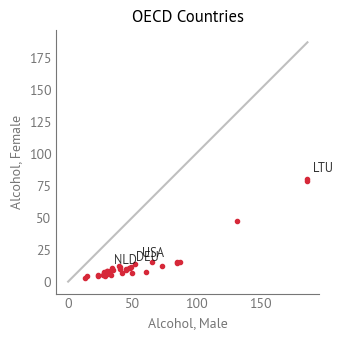

In [32]:
col = 'AlcoholDeathRate'
alcohol = alcohol.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
alcohol_gap, alcohol_recent = summarize_gap(alcohol, col)

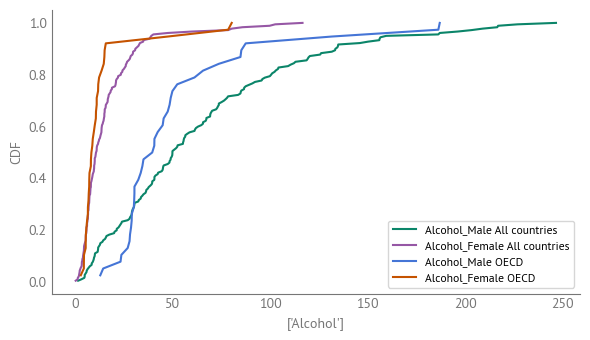

In [33]:
plot_distributions(alcohol_recent)

## Poison

**Mortality rate attributed to unintentional poisoning (per 100,000 population)** - Deaths from accidental poisonings from chemicals, drugs, and other substances.

**Indicator Code**: SDGPOISON  
**Relevance**: Men often have higher rates of accidental deaths, including poisonings. This reflects occupational hazards and risk-taking behaviors that contribute to the gender gap in mortality. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [34]:
filename = '../data/who_poisoning_rates.csv'
poison, years = load_and_inventory(filename)

(11100, 12)
['SDGPOISON']
['Mortality rate attributed to unintentional poisoning (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'G

In [35]:
poison.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,PoisoningRate,PoisoningRate_Low,PoisoningRate_High,Comments,DataSource,Country
0,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2000,Both sexes,3.272761,1.091069,6.816218,NaN,NaN,Afghanistan
1,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2001,Both sexes,3.351724,1.157869,6.926548,NaN,NaN,Afghanistan
2,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2002,Both sexes,3.038659,0.946774,6.704357,NaN,NaN,Afghanistan
3,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2003,Both sexes,3.689834,1.521052,7.401055,NaN,NaN,Afghanistan
4,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2004,Both sexes,3.681742,1.573983,7.347575,NaN,NaN,Afghanistan


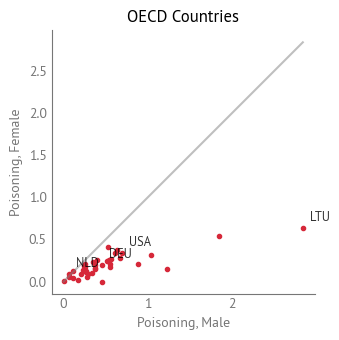

In [36]:
col = 'PoisoningRate'
poison = poison.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
poison_gap, poison_recent = summarize_gap(poison, col)

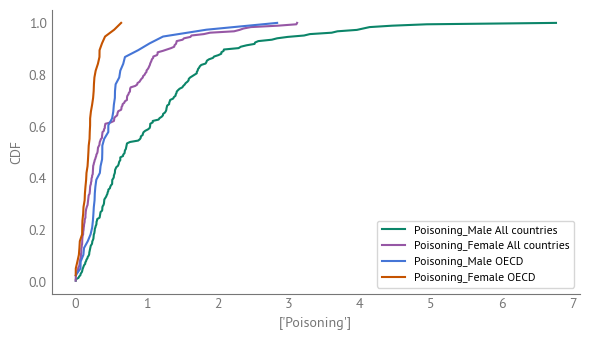

In [37]:
plot_distributions(poison_recent)

## Traffic

**Road traffic crash deaths, age-standardized death rates (15+), per 100,000 population** - Deaths from road traffic accidents, age-standardized for ages 15+.

**Indicator Code**: SA_0000001459  
**Relevance**: Road traffic deaths are typically 2-4 times higher in men across most countries, making it a major contributor to the gender gap in mortality. Reflects higher exposure to driving (including occupational exposure), occupational hazards, and potentially risk-taking behaviors. Age-standardized rates for ages 15+ match HALE methodology.

In [38]:
filename = '../data/who_road_traffic_death_rates.csv'
traffic, years = load_and_inventory(filename)

(540, 12)
['SA_0000001459']
['Road traffic crash deaths, age-standardized death rates (all ages), per 100,000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece'
 'Grenada' 'Guatemala' 'Guyan

In [39]:
traffic.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,RoadTrafficDeathRate,RoadTrafficDeathRate_Low,RoadTrafficDeathRate_High,Comments,DataSource,Country
0,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Both sexes,19.806936,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Female,8.323253,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Male,30.823815,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Both sexes,30.060828,NaN,NaN,NaN,NaN,Angola
4,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Female,18.692964,NaN,NaN,NaN,NaN,Angola


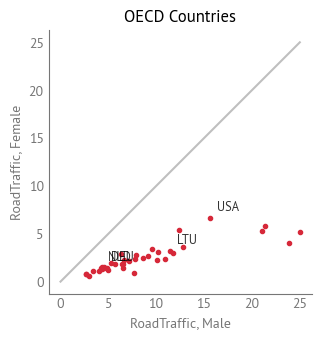

In [40]:
col = 'RoadTrafficDeathRate'
traffic = traffic.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
traffic_gap, traffic_recent = summarize_gap(traffic, col)

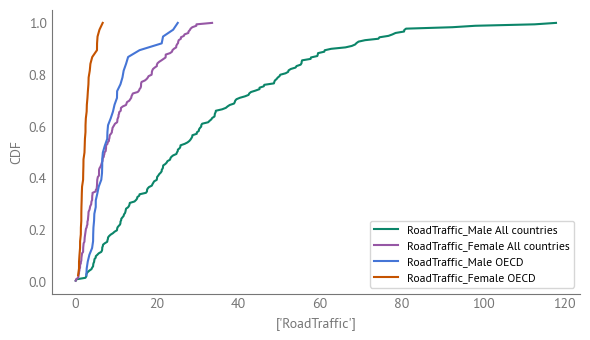

In [41]:
plot_distributions(traffic_recent)

## Maternal mortality

**Maternal mortality ratio (per 100,000 live births)** - Deaths of women during pregnancy, childbirth, or within 42 days of termination of pregnancy, per 100,000 live births.

**Indicator Code**: MDG_0000000026  
**Relevance**: Critical for understanding cases where the HALE gender gap is small due to high female mortality, especially in lower-income countries. High maternal mortality can significantly reduce the HALE gender gap by lowering female life expectancy. Inherently female-specific, so only female values are used in analysis.

In [42]:
filename = '../data/who_maternal_mortality_ratio.csv'
maternal, years = load_and_inventory(filename)

(3900, 12)
['MDG_0000000026']
['Maternal mortality ratio (per 100 000 live births)']
['Female']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['Afghanistan' 'Angola' 'Albania' 'Andorra' 'United Arab Emirates'
 'Argentina' 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria'
 'Azerbaijan' 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh'
 'Bulgaria' 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize'
 'Bolivia' 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Cook Islands' 'Colombia'
 'Comoros' 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany'
 'Djibouti' nan 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt'
 'Eritrea' 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea

In [43]:
maternal.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,MaternalMortalityRatio,MaternalMortalityRatio_Low,MaternalMortalityRatio_High,Comments,DataSource,Country
0,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2000,Female,1371.645908,937.495878,1828.321863,NaN,NaN,Afghanistan
1,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2001,Female,1310.954923,906.872935,1734.166876,NaN,NaN,Afghanistan
2,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2002,Female,1262.516681,884.408915,1652.739115,NaN,NaN,Afghanistan
3,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2003,Female,1201.381450,857.173518,1567.186347,NaN,NaN,Afghanistan
4,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2004,Female,1166.469374,849.256289,1515.271527,NaN,NaN,Afghanistan


In [44]:
col = 'MaternalMortalityRatio'
maternal = maternal.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
maternal_gap, maternal_recent = summarize_gap(maternal, col, sexes=['Female'])

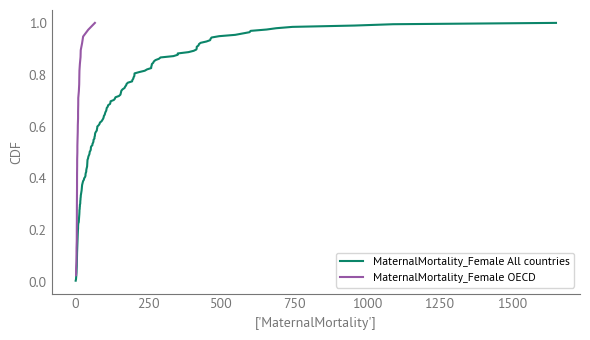

In [45]:
plot_distributions(maternal_recent)

## Homicide

**Estimates of rates of homicides per 100,000 population** - Deaths from intentional homicide, including estimates with confidence intervals.

**Indicator Code**: VIOLENCE_HOMICIDERATE  
**Relevance**: Homicide rates are typically much higher in men across most countries, making it a major contributor to the gender gap in mortality. Homicide reflects violence, conflict, and social factors that differentially affect men and women. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [46]:
filename = '../data/who_homicide_rates.csv'
homicide, years = load_and_inventory(filename)

(11100, 12)
['VIOLENCE_HOMICIDERATE']
['Estimates of rates of homicides per 100 000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Gui

In [47]:
homicide.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,HomicideRate,HomicideRate_Low,HomicideRate_High,Comments,DataSource,Country
0,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2000,Both sexes,10.433863,5.581236,16.844870,NaN,NaN,Afghanistan
1,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2001,Both sexes,10.617865,5.678589,17.162430,NaN,NaN,Afghanistan
2,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2002,Both sexes,10.953708,6.568415,16.902796,NaN,NaN,Afghanistan
3,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2003,Both sexes,10.781847,6.539156,16.757218,NaN,NaN,Afghanistan
4,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2004,Both sexes,10.135798,5.742813,16.420052,NaN,NaN,Afghanistan


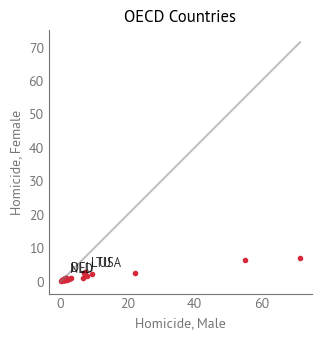

In [48]:
col = 'HomicideRate'
homicide = homicide.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
homicide_gap, homicide_recent = summarize_gap(homicide, col)

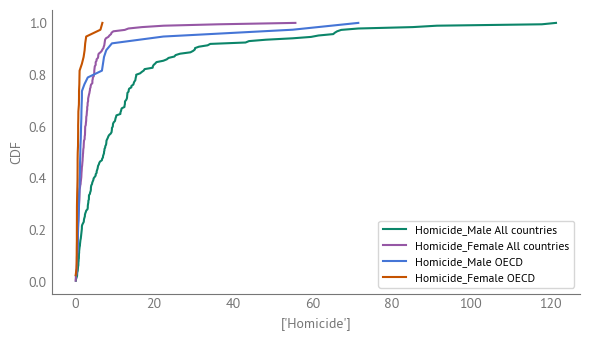

In [49]:
plot_distributions(homicide_recent)

## Intimate Partner Violence

**Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months (%)** - Prevalence indicator measuring the percentage of women experiencing intimate partner violence.

**Indicator Code**: SDGIPV  
**Relevance**: Note: This is a **prevalence indicator** (percentage), not a direct death rate. IPV affects women's health indirectly through mental health impacts, injuries, and other health consequences. It may contribute to the gender gap in HALE through its effects on women's physical and mental health, though the relationship is complex and indirect. Inherently female-specific, so only female values are used in analysis.

In [50]:
filename = '../data/who_ipv_prevalence.csv'
ipv, years = load_and_inventory(filename)

(558, 12)
['SDGIPV']
['Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months']
['Female']
['DHS '
 'calculated by FRA based on available country data from the 2012 FRA Violence against women: an EU-wide Survey  Women aged 18-74; definition of physical and sexual violence differs from the standard'
 'Violence against Women Survey 2015 '
 'Calculated by UNFPA based on available country data from the Violence against Women Survey 2015 UNECE methodology; women aged 15+'
 'PAHO 2018 publication Intimate Partner Violence against Women in the Americas: calculated by PAHO based on available country data from the Encuesta de Prevalencia y Caracteristicas de la Violencia contra las Mujeres 2016 ~ENDIREH methodology; women aged 15+; definition of sexual violence differs from the standard'
 'MICS ' 'DHS Currently married'
 'DHS Refers to currently married girls and women'
 'The Co

In [51]:
ipv.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,IPVPrevalence,IPVPrevalence_Low,IPVPrevalence_High,Comments,DataSource,Country
18,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.1,NaN,NaN,DHS,NaN,Afghanistan
19,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,45.2,NaN,NaN,DHS,NaN,Afghanistan
20,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,51.9,NaN,NaN,DHS,NaN,Afghanistan
21,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.3,NaN,NaN,DHS,NaN,Afghanistan
22,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,48.6,NaN,NaN,DHS,NaN,Afghanistan


In [52]:
col = 'IPVPrevalence'
year = years[-1]
ipv_gap, ipv_recent = summarize_gap(ipv, col, sexes=['Female'])

/tmp/ipykernel_970046/2285234875.py:27: UserWarning: Missing 12 OECD countries in data: ['AUS', 'CAN', 'CHE', 'CHL', 'CRI', 'ISL', 'ISR', 'JPN', 'KOR', 'NOR', 'NZL', 'USA']
  warnings.warn(


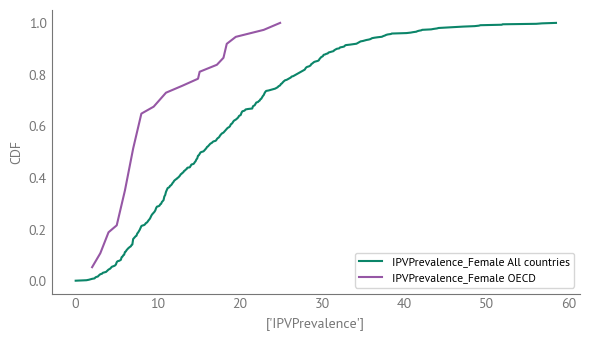

In [53]:
plot_distributions(ipv_recent)

## Under five mortality rate

**Under-five mortality rate (probability of dying by age 5 per 1000 live births)** - Deaths of children under age 5 per 1,000 live births, with gender breakdowns.

**Indicator Code**: MDG_0000000007  
**Relevance**: HALE is calculated from birth, so under-five mortality directly affects HALE calculations. If child mortality differs by gender, it directly contributes to the HALE gender gap. Infant mortality is typically higher in males (biological vulnerability + some behavioral factors). More important in lower-income countries with high child mortality. Note: MDG_0000000007 chosen over u5mr for better data quality when filtered for sex dimension.

In [54]:
filename = '../data/who_u5mr.csv'
u5mr, years = load_and_inventory(filename)

(22600, 12)
['MDG_0000000007']
['Under-five mortality rate (probability of dying by age 5 per 1000 live births)']
['Both sexes' 'Female' 'Male']
[nan
 'Some UN IGME indicators are calculated using population and live birth numbers from the World Population Prospects: The 2024 revision (WPP). The WPP numbers for Cyprus refer to the entire country. However, the underlying data used to calculate mortality rates estimates, provided by the Health Monitoring Unit of the Cyprus Ministry of Health, cover only the government-controlled areas, whereas according to Eurostat, the number of live births in 2023 was 10,295 (https://ec.europa.eu/eurostat/databrowser/view/tps00204/), the population on 1 January 2023 was 920,701 (https://ec.europa.eu/eurostat/databrowser/view/tps00001/), the population under 5 was 49,326,  adolescent population was 99,207 and the number of women of reproductive age was 235,268 (https://doi.org/10.2908/DEMO_PJAN).'
 'The UN IGME estimates are not the official statistics 

In [55]:
u5mr.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,U5MR,U5MR_Low,U5MR_High,Comments,DataSource,Country
0,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,131.657158,122.050144,142.254414,NaN,NaN,Afghanistan
1,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,146.404320,129.690344,164.793287,NaN,NaN,Afghanistan
2,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,116.604951,101.901270,133.012767,NaN,NaN,Afghanistan
3,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,139.669993,126.880951,153.782482,NaN,NaN,Afghanistan
4,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,92.831046,79.709380,107.613673,NaN,NaN,Afghanistan


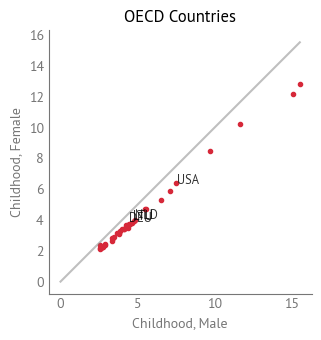

In [56]:
col = 'U5MR'
u5mr = u5mr.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
u5mr_gap, u5mr_recent = summarize_gap(u5mr, col)

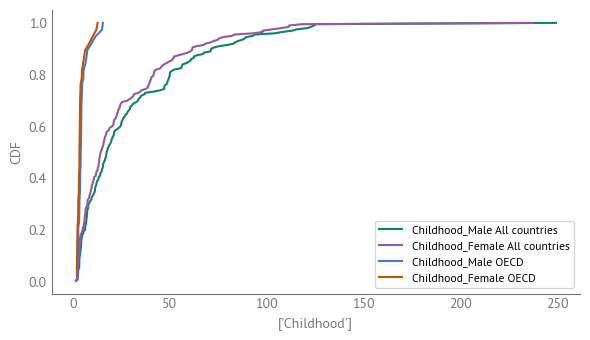

In [57]:
plot_distributions(u5mr_recent)

## Cardiovascular Disease

**Age-standardized cardiovascular disease death rates (per 100,000)** - Deaths from cardiovascular diseases (heart disease, stroke, etc.), age-standardized for cross-country comparison.

**Indicator Code**: Multiple codes tried (WHS2_161, etc.) - see `who_data.py` for implementation details  
**Relevance**: Men typically have higher rates of cardiovascular disease and heart attacks, contributing significantly to the gender gap in mortality. Risk factors include smoking, diet, and potentially biological differences. May capture effects of smoking and other risk factors. Age-standardized rates match HALE methodology.

In [58]:
filename = '../data/who_cardiovascular_death_rates.csv'
cardio, years = load_and_inventory(filename)

(573, 12)
['SA_0000001444']
[nan]
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['Afghanistan' 'Angola' 'Albania' 'Andorra' 'United Arab Emirates'
 'Argentina' 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria'
 'Azerbaijan' 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh'
 'Bulgaria' 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize'
 'Bolivia' 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Cook Islands' 'Colombia'
 'Comoros' 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany'
 'Djibouti' nan 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt'
 'Eritrea' 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece'
 'Grenada' 'Guatemala' 'Guyana' 'Honduras' 'Croatia' 'Haiti' 'Hungary'
 'Indonesia' 'Indi

In [59]:
# Rename DeathRate to CardioDeathRate to avoid ambiguity
cardio = cardio.rename(columns={'DeathRate': 'CardioDeathRate'})
cardio.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,CardioDeathRate,DeathRate_Low,DeathRate_High,Comments,DataSource,Country
0,SA_0000001444,NaN,AFG,COUNTRY,2004,Both sexes,366.9,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001444,NaN,AFG,COUNTRY,2004,Female,282.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001444,NaN,AFG,COUNTRY,2004,Male,447.4,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001444,NaN,AGO,COUNTRY,2004,Both sexes,142.4,NaN,NaN,NaN,NaN,Angola
4,SA_0000001444,NaN,AGO,COUNTRY,2004,Female,111.0,NaN,NaN,NaN,NaN,Angola


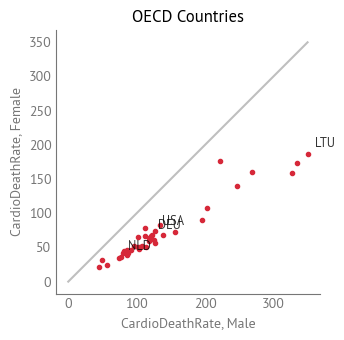

In [60]:
col = 'CardioDeathRate'
year = years[-1]
cardio_gap, cardio_recent = summarize_gap(cardio, col)

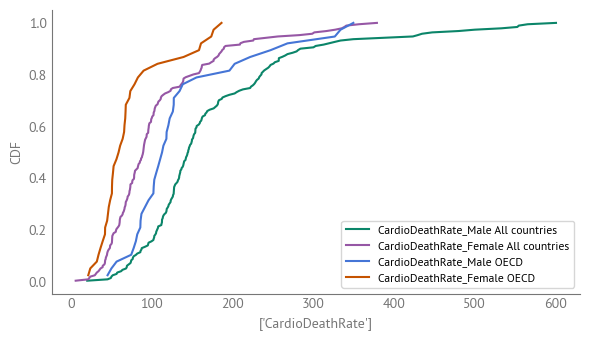

In [61]:
plot_distributions(cardio_recent)

## Diabetes

**Age-standardized death rates, diabetes mellitus (per 100,000)** - Deaths from diabetes, age-standardized for cross-country comparison.

**Indicator Code**: SA_0000001440  
**Relevance**: Diabetes is a chronic condition that can contribute to the gender gap in mortality, though the relationship may vary by country and healthcare access. Age-standardized rates match HALE methodology. **Limitation**: Only has data for 2004 (similar to cardiovascular disease indicators), which limits temporal analysis but provides a good cross-sectional snapshot.

In [62]:
filename = '../data/who_diabetes_death_rates.csv'
diabetes, years = load_and_inventory(filename)

(573, 12)
['SA_0000001440']
['Age-standardized death rates, diabetes mellitus, per 100,000']
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['Afghanistan' 'Angola' 'Albania' 'Andorra' 'United Arab Emirates'
 'Argentina' 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria'
 'Azerbaijan' 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh'
 'Bulgaria' 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize'
 'Bolivia' 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Cook Islands' 'Colombia'
 'Comoros' 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany'
 'Djibouti' nan 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt'
 'Eritrea' 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of Micronesia' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece'
 'Grenada' 'Guatemala' 'Guyana

In [63]:
diabetes.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,Comments,DataSource,Country
0,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Both sexes,29.3,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Female,30.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Male,27.5,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Both sexes,67.6,NaN,NaN,NaN,NaN,Angola
4,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Female,74.2,NaN,NaN,NaN,NaN,Angola


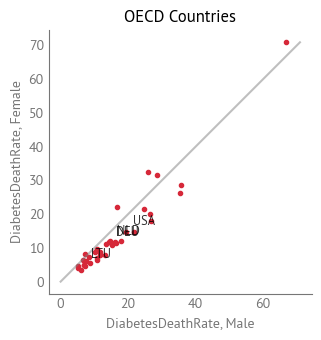

In [64]:
col = 'DiabetesDeathRate'
year = years[-1]
diabetes_gap, diabetes_recent = summarize_gap(diabetes, col)

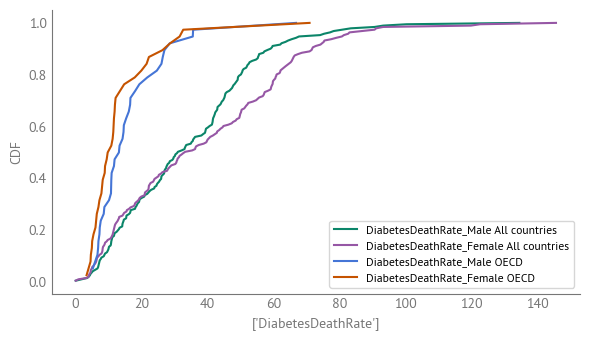

In [65]:
plot_distributions(diabetes_recent)

## NCD Mortality (30-70 years)

**Probability (%) of dying between age 30 and exact age 70 from any of cardiovascular disease, cancer, diabetes, or chronic respiratory disease** - Combined non-communicable disease mortality indicator.

**Indicator Code**: NCDMORT3070  
**Relevance**: Combines multiple causes of death (cardiovascular disease, cancer, diabetes, chronic respiratory disease), so it's less specific than individual cause indicators. However, it has much better temporal coverage (2000-2021) than diabetes-specific indicators (which only have 2004 data). This makes it useful for model comparison - trading off specificity for temporal coverage. The combined indicator may capture overall NCD mortality patterns that contribute to the HALE gender gap.

In [66]:
filename = '../data/who_ncd_mortality_30_70.csv'
ncdmort, years = load_and_inventory(filename)

(11100, 12)
['NCDMORT3070']
['Probability (%) of dying between age 30 and exact age 70 from any of cardiovascular disease, cancer, diabetes, or chronic respiratory disease']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan'
 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria'
 'Bahrain' 'Bahamas' 'Bosnia-Herzegovina' 'Belarus' 'Belize' 'Bolivia'
 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte D'Ivoire" 'Cameroon' 'D.R. Congo' 'Congo' 'Colombia' 'Comoros'
 'Cape Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Federated States of M

In [67]:
ncdmort.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,NCDMortality30_70,NCDMortality30_70_Low,NCDMortality30_70_High,Comments,DataSource,Country
0,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2000,Both sexes,43.2,25.6,60.0,NaN,NaN,Afghanistan
1,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2001,Both sexes,43.5,25.8,60.3,NaN,NaN,Afghanistan
2,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2002,Both sexes,43.1,25.7,60.2,NaN,NaN,Afghanistan
3,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2003,Both sexes,42.5,25.6,60.1,NaN,NaN,Afghanistan
4,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2004,Both sexes,42.3,25.6,60.0,NaN,NaN,Afghanistan


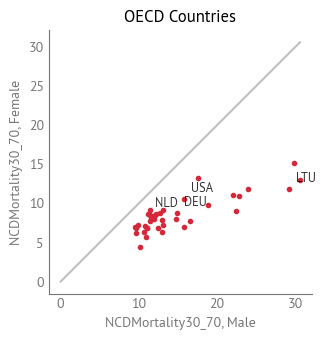

In [68]:
col = 'NCDMortality30_70'
year = years[-1]
ncdmort_gap, ncdmort_recent = summarize_gap(ncdmort, col)

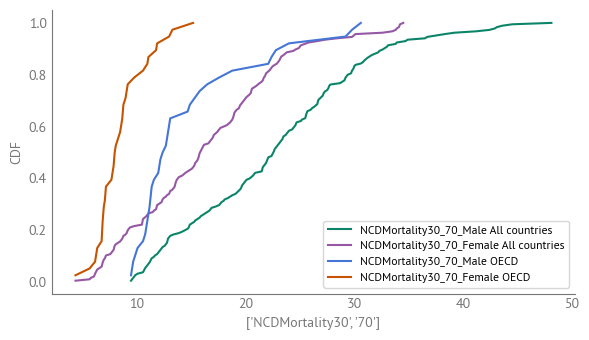

In [69]:
plot_distributions(ncdmort_recent)

## Drug Use Disorders (IHME)

**Drug use disorder death rates (per 100,000 population)** - Deaths from drug use disorders, including overdoses, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Drug overdoses, particularly opioid overdoses, are a major cause of death in some OECD countries (especially the US) and may contribute significantly to the HALE gender gap. This indicator captures overdose deaths that may not be fully captured in the WHO poisoning indicator. Data includes separate male and female values, allowing for gender gap analysis.

In [70]:
def load_ihme_indicator(filename_male, filename_female, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data from separate male and female files and convert to WHO-compatible format.
    
    Converts IHME CSV format (Location=country name, Sex="Male"/"Female") to WHO format
    (Country=country code, Sex="Male"/"Female", etc.). Filters to 2000-2019.
    
    Parameters
    ----------
    filename_male : str
        Path to the IHME CSV file with male data.
    filename_female : str
        Path to the IHME CSV file with female data.
    value_col_name : str
        Name for the value column (e.g., 'DrugDisorderDeathRate', 'DiabetesDeathRate').
    indicator_code : str
        Indicator code for the IHME indicator (e.g., 'IHME_DRUG_DISORDERS', 'IHME_DIABETES_TYPE2').
    indicator_name : str
        Human-readable indicator name (e.g., 'Drug use disorders, death rate per 100,000').
        
    Returns
    -------
    df : pandas.DataFrame
        DataFrame in WHO-compatible format with columns: IndicatorCode, IndicatorName,
        Code, CountryCode, Year, Sex, value_col_name, value_col_name_Low, 
        value_col_name_High, Country.
    years : numpy.ndarray
        Array of unique years present in the filtered dataset.
    """
    # Create reverse mapping from country name to code
    who_country_to_code = {country: code for code, country in code_to_who_country.items()}
    
    # Map IHME country names that differ from WHO names
    ihme_country_name_mapping = {
        'Republic of Korea': 'South Korea',
        'United States of America': 'United States'
    }
    
    def process_ihme_file(filename, sex_value):
        """Helper function to process a single IHME file."""
        df = pd.read_csv(filename)
        
        # Filter to 2000-2019 (exclude 2020+ for COVID-19 reasons)
        df = df.query('Year >= 2000 and Year <= 2019')
        
        # Filter to "All ages" (if Age column exists)
        if 'Age' in df.columns:
            df = df.query('Age == "All ages"')
        
        # Map IHME country names to WHO country names
        df['Location'] = df['Location'].replace(ihme_country_name_mapping)
        
        # Convert country names to codes
        df['Code'] = df['Location'].map(who_country_to_code)
        
        # Filter out rows where country mapping failed (not in our country list)
        df = df[df['Code'].notna()].copy()
        
        # Set Sex column to the specified value (Male or Female)
        df['Sex'] = sex_value
        
        # Rename and create columns to match WHO format
        df['IndicatorCode'] = indicator_code
        df['IndicatorName'] = indicator_name
        df['CountryCode'] = 'COUNTRY'
        df[value_col_name] = df['Value']
        df[f'{value_col_name}_Low'] = df['Lower bound']
        df[f'{value_col_name}_High'] = df['Upper bound']
        df['Country'] = df['Location']
        
        # Select and reorder columns to match WHO format
        columns_to_keep = [
            'IndicatorCode', 'IndicatorName', 'Code', 'CountryCode', 'Year', 'Sex',
            value_col_name, f'{value_col_name}_Low', f'{value_col_name}_High',
            'Country'
        ]
        df = df[columns_to_keep].copy()
        
        return df
    
    # Load and process both files
    df_male = process_ihme_file(filename_male, 'Male')
    df_female = process_ihme_file(filename_female, 'Female')
    
    # Concatenate male and female data
    df = pd.concat([df_male, df_female], ignore_index=True)
    
    # Sort by country, sex, and year
    df = df.sort_values(['Country', 'Sex', 'Year']).reset_index(drop=True)
    
    years = df['Year'].unique()
    
    print(df.shape)
    print(f"Years: {years.min():.0f} - {years.max():.0f}")
    print(f"Countries: {df['Country'].nunique()}")
    print(f"Sex categories: {df['Sex'].unique()}")
    
    return df, years

In [71]:
filename_male = '../data/ihme_drug_disorder_deaths_male.csv'
filename_female = '../data/ihme_drug_disorder_deaths_female.csv'
drug_disorders, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='DrugDisorderDeathRate',
    indicator_code='IHME_DRUG_DISORDERS',
    indicator_name='Drug use disorders, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [72]:
drug_disorders.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,DrugDisorderDeathRate,DrugDisorderDeathRate_Low,DrugDisorderDeathRate_High,Country
0,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2000.0,Female,2.882676,2.484026,3.362499,Australia
1,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2001.0,Female,2.664587,2.285326,3.074588,Australia
2,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2002.0,Female,2.499320,2.146495,2.925388,Australia
3,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2003.0,Female,2.420756,2.069723,2.821397,Australia
4,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2004.0,Female,2.357760,2.019524,2.738372,Australia


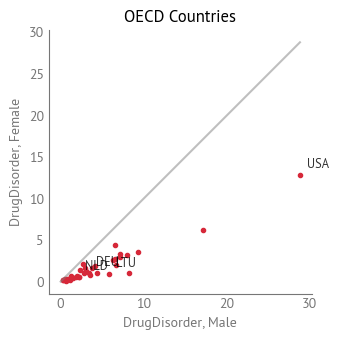

In [73]:
col = 'DrugDisorderDeathRate'
drug_disorders = drug_disorders.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
drug_disorders_gap, drug_disorders_recent = summarize_gap(drug_disorders, col)

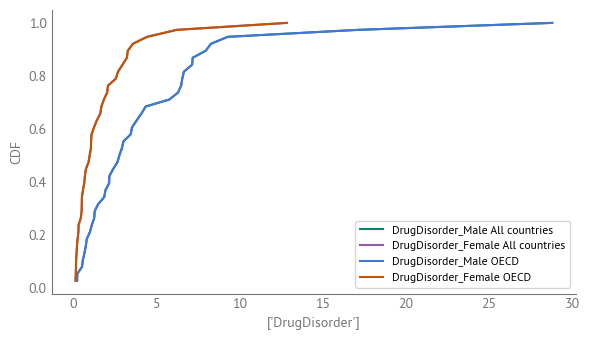

In [74]:
plot_distributions(drug_disorders_recent)

## Diabetes Type 2 (IHME)

**Diabetes type 2 death rates (per 100,000 population)** - Deaths from diabetes mellitus type 2, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: This is an alternative to the WHO diabetes death rate indicator (SA_0000001440) which only has data for 2004. IHME data may have better temporal coverage, allowing for more recent data to be used in the analysis. Diabetes is a chronic condition that can contribute to the gender gap in mortality, though the relationship may vary by country and healthcare access. Data includes separate male and female values, allowing for gender gap analysis.

In [75]:
filename_male = '../data/ihme_diabetes_deaths_male.csv'
filename_female = '../data/ihme_diabetes_deaths_female.csv'
diabetes_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='DiabetesDeathRate',
    indicator_code='IHME_DIABETES_TYPE2',
    indicator_name='Diabetes mellitus type 2, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [76]:
diabetes_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,Country
0,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2000.0,Female,14.248627,12.464444,15.401741,Australia
1,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2001.0,Female,14.344688,12.349151,15.524031,Australia
2,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2002.0,Female,14.975359,12.788477,16.260285,Australia
3,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2003.0,Female,15.525666,13.304746,16.804496,Australia
4,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2004.0,Female,16.080445,13.757866,17.471747,Australia


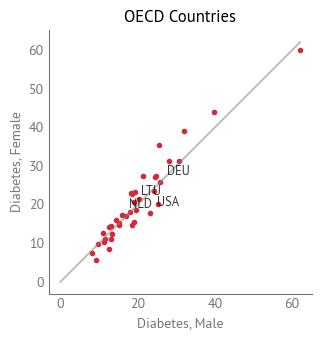

In [77]:
col = 'DiabetesDeathRate'
diabetes_ihme = diabetes_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
diabetes_ihme_gap, diabetes_ihme_recent = summarize_gap(diabetes_ihme, col)

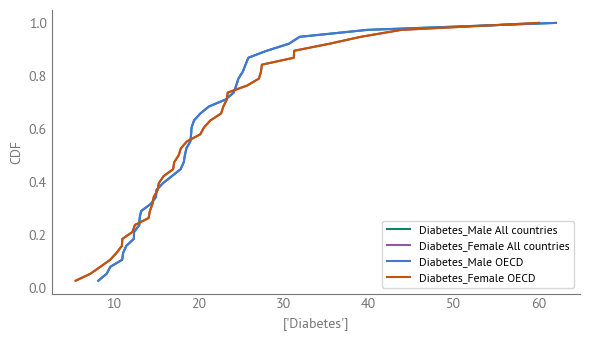

In [78]:
plot_distributions(diabetes_ihme_recent)

## Cardiovascular Diseases (IHME)

**Cardiovascular diseases death rates (per 100,000 population)** - Deaths from cardiovascular diseases, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Cardiovascular diseases are a major cause of death and may contribute significantly to the HALE gender gap. This is an alternative to the WHO cardiovascular disease death rate indicators which only have data for 2004. IHME data may have better temporal coverage, allowing for more recent data to be used in the analysis. Data includes separate male and female values, allowing for gender gap analysis.

In [79]:
filename_male = '../data/ihme_cardiovascular_deaths_male.csv'
filename_female = '../data/ihme_cardiovascular_deaths_female.csv'
cardiovascular_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='CardioDeathRate',
    indicator_code='IHME_CARDIOVASCULAR',
    indicator_name='Cardiovascular diseases, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [80]:
cardiovascular_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,CardioDeathRate,CardioDeathRate_Low,CardioDeathRate_High,Country
0,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2000.0,Female,259.494605,222.004192,280.150209,Australia
1,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2001.0,Female,253.477767,215.393916,274.406489,Australia
2,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2002.0,Female,253.122588,214.641706,274.256619,Australia
3,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2003.0,Female,244.429433,205.859935,264.521285,Australia
4,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2004.0,Female,235.278983,195.651019,255.862336,Australia


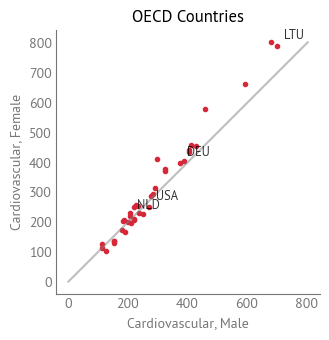

In [81]:
col = 'CardioDeathRate'
cardiovascular_ihme = cardiovascular_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
cardiovascular_ihme_gap, cardiovascular_ihme_recent = summarize_gap(cardiovascular_ihme, col)

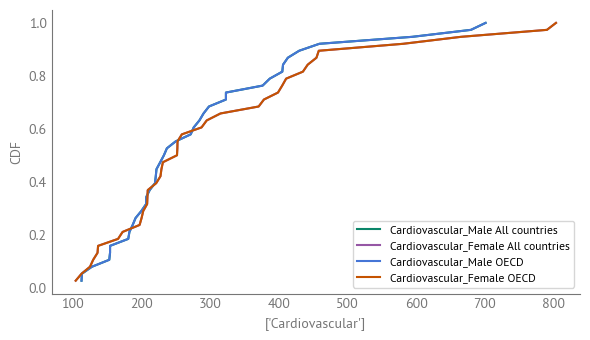

In [82]:
plot_distributions(cardiovascular_ihme_recent)

## Neoplasms (Cancer) (IHME)

**Neoplasms (cancer) death rates (per 100,000 population)** - Deaths from neoplasms (cancer), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Neoplasms (cancer) are a major cause of death and may contribute significantly to the HALE gender gap. Different types of cancer have different gender patterns (e.g., lung cancer is often higher in men, breast cancer is female-specific). This indicator provides comprehensive cancer death rates with better temporal coverage than WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [83]:
filename_male = '../data/ihme_neoplasms_deaths_male.csv'
filename_female = '../data/ihme_neoplasms_deaths_female.csv'
neoplasms_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='NeoplasmsDeathRate',
    indicator_code='IHME_NEOPLASMS',
    indicator_name='Neoplasms (cancer), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [84]:
neoplasms_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,NeoplasmsDeathRate,NeoplasmsDeathRate_Low,NeoplasmsDeathRate_High,Country
0,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2000.0,Female,174.372594,157.339856,183.123589,Australia
1,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2001.0,Female,176.862341,159.525714,186.065679,Australia
2,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2002.0,Female,179.519671,162.651746,189.101742,Australia
3,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2003.0,Female,178.595845,160.978354,188.735833,Australia
4,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2004.0,Female,177.584662,159.143525,187.692801,Australia


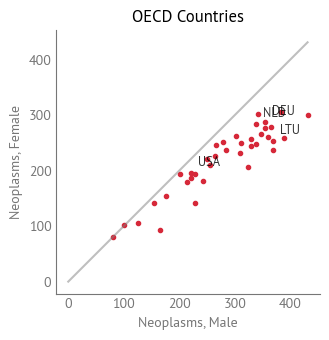

In [85]:
col = 'NeoplasmsDeathRate'
neoplasms_ihme = neoplasms_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
neoplasms_ihme_gap, neoplasms_ihme_recent = summarize_gap(neoplasms_ihme, col)

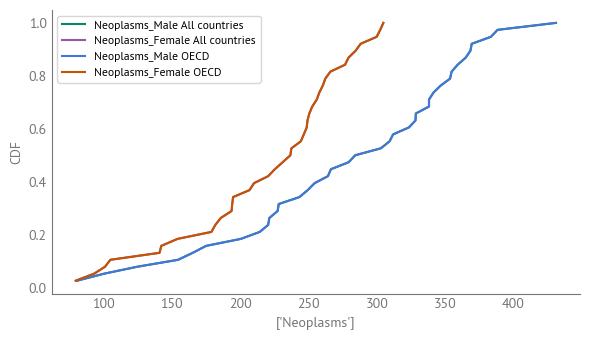

In [86]:
plot_distributions(neoplasms_ihme_recent)

## Chronic Respiratory Diseases (IHME)

**Chronic respiratory diseases death rates (per 100,000 population)** - Deaths from chronic respiratory diseases (including COPD, asthma, and other chronic lung conditions), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Chronic respiratory diseases are a major cause of death and may contribute significantly to the HALE gender gap. These diseases often have gender differences due to factors such as smoking patterns, occupational exposures, and environmental factors. This indicator provides comprehensive chronic respiratory disease death rates with better temporal coverage than WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [87]:
filename_male = '../data/ihme_chronic_respiratory_deaths_male.csv'
filename_female = '../data/ihme_chronic_respiratory_deaths_female.csv'
chronic_respiratory_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='ChronicRespiratoryDeathRate',
    indicator_code='IHME_CHRONIC_RESPIRATORY',
    indicator_name='Chronic respiratory diseases, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [88]:
chronic_respiratory_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,ChronicRespiratoryDeathRate,ChronicRespiratoryDeathRate_Low,ChronicRespiratoryDeathRate_High,Country
0,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2000.0,Female,33.416935,29.058943,36.594912,Australia
1,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2001.0,Female,33.538075,29.034905,36.751005,Australia
2,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2002.0,Female,34.771695,30.095679,38.050192,Australia
3,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2003.0,Female,34.102959,29.234623,37.388706,Australia
4,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2004.0,Female,33.381971,28.496299,37.070731,Australia


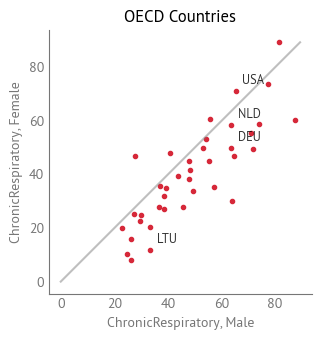

In [89]:
col = 'ChronicRespiratoryDeathRate'
chronic_respiratory_ihme = chronic_respiratory_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
chronic_respiratory_ihme_gap, chronic_respiratory_ihme_recent = summarize_gap(chronic_respiratory_ihme, col)

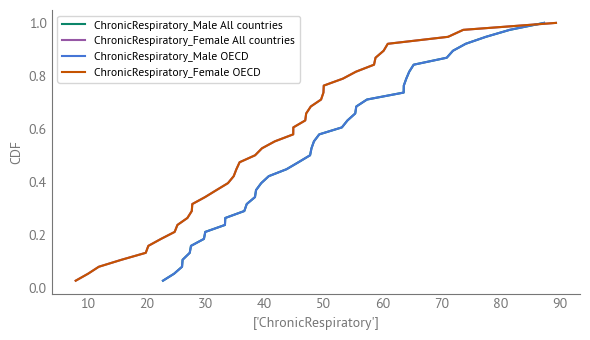

In [90]:
plot_distributions(chronic_respiratory_ihme_recent)

## Unintentional Injuries (IHME)

**Unintentional injuries death rates (per 100,000 population)** - Deaths from unintentional injuries (including falls, drowning, fires, and other accidents), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Unintentional injuries are a significant cause of death and may contribute to the HALE gender gap. These injuries often show gender differences due to occupational exposures, risk-taking behaviors, and activity patterns. This indicator provides comprehensive unintentional injury death rates with better temporal coverage (1990-2023) than many WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [91]:
filename_male = '../data/ihme_unintentional_injuries_deaths_male.csv'
filename_female = '../data/ihme_unintentional_injuries_deaths_female.csv'
unintentional_injuries_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='UnintentionalInjuriesDeathRate',
    indicator_code='IHME_UNINTENTIONAL_INJURIES',
    indicator_name='Unintentional injuries, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [92]:
unintentional_injuries_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,UnintentionalInjuriesDeathRate,UnintentionalInjuriesDeathRate_Low,UnintentionalInjuriesDeathRate_High,Country
0,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2000.0,Female,12.032874,10.437510,13.670943,Australia
1,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2001.0,Female,11.824066,10.182373,13.412276,Australia
2,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2002.0,Female,12.696670,10.897320,14.482235,Australia
3,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2003.0,Female,13.010010,11.096530,14.885208,Australia
4,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2004.0,Female,13.977934,11.937847,15.891603,Australia


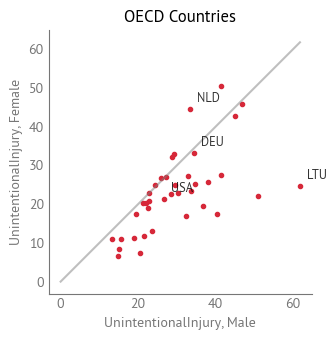

In [93]:
col = 'UnintentionalInjuriesDeathRate'
unintentional_injuries_ihme = unintentional_injuries_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
unintentional_injuries_ihme_gap, unintentional_injuries_ihme_recent = summarize_gap(unintentional_injuries_ihme, col)

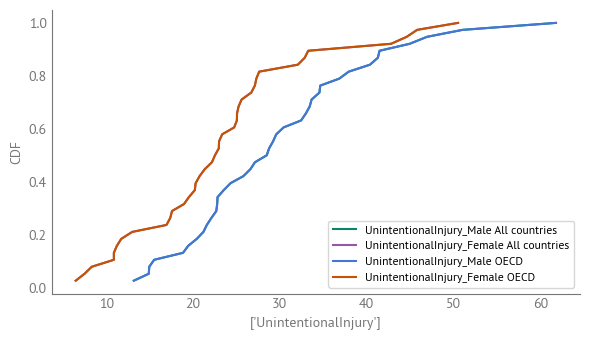

In [94]:
plot_distributions(unintentional_injuries_ihme_recent)

## Alcohol Use Disorders (IHME)

**Alcohol use disorders death rates (per 100,000 population)** - Deaths from alcohol use disorders, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Alcohol use disorders are a significant cause of death and may contribute to the HALE gender gap. Men typically have higher rates of alcohol-related mortality than women. This indicator provides comprehensive alcohol use disorder death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO alcohol-attributable death rate indicator (SA_0000001832) which only has data for 2019. IHME data provides much better temporal coverage, allowing for temporal analysis and more recent data. Data includes separate male and female values, allowing for gender gap analysis.

In [95]:
filename_male = '../data/ihme_alcohol_use_disorders_deaths_male.csv'
filename_female = '../data/ihme_alcohol_use_disorders_deaths_female.csv'
alcohol_use_disorders_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='AlcoholUseDisordersDeathRate',
    indicator_code='IHME_ALCOHOL_USE_DISORDERS',
    indicator_name='Alcohol use disorders, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [96]:
alcohol_use_disorders_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,AlcoholUseDisordersDeathRate,AlcoholUseDisordersDeathRate_Low,AlcoholUseDisordersDeathRate_High,Country
0,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2000.0,Female,0.631488,0.531539,0.744281,Australia
1,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2001.0,Female,0.616363,0.515268,0.734888,Australia
2,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2002.0,Female,0.672539,0.559962,0.802278,Australia
3,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2003.0,Female,0.680933,0.564946,0.810902,Australia
4,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2004.0,Female,0.704165,0.587091,0.828949,Australia


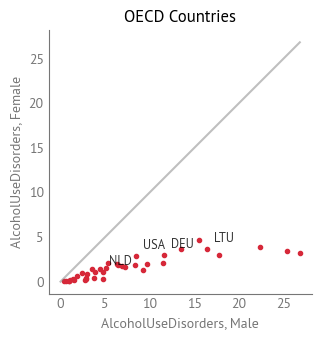

In [97]:
col = 'AlcoholUseDisordersDeathRate'
alcohol_use_disorders_ihme = alcohol_use_disorders_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
alcohol_use_disorders_ihme_gap, alcohol_use_disorders_ihme_recent = summarize_gap(alcohol_use_disorders_ihme, col)

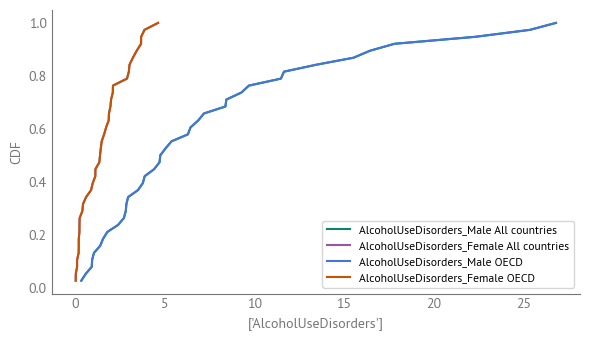

In [98]:
plot_distributions(alcohol_use_disorders_ihme_recent)

## Self-Harm (IHME)

**Self-harm (suicide) death rates (per 100,000 population)** - Deaths from self-harm (suicide), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Self-harm (suicide) is a significant cause of death and contributes to the HALE gender gap. Men typically have much higher suicide rates than women in most countries. This indicator provides comprehensive self-harm death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO suicide rate indicator (MH_12) which has data for 2000-2021. IHME data provides slightly better temporal coverage (starting from 1990) and may have different methodology or data sources. Data includes separate male and female values, allowing for gender gap analysis.

In [99]:
filename_male = '../data/ihme_self_harm_deaths_male.csv'
filename_female = '../data/ihme_self_harm_deaths_female.csv'
self_harm_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='SelfHarmDeathRate',
    indicator_code='IHME_SELF_HARM',
    indicator_name='Self-harm (suicide), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [100]:
self_harm_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,SelfHarmDeathRate,SelfHarmDeathRate_Low,SelfHarmDeathRate_High,Country
0,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2000.0,Female,5.627537,5.216050,6.147375,Australia
1,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2001.0,Female,5.677859,5.274716,6.153598,Australia
2,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2002.0,Female,5.484698,5.066802,5.936228,Australia
3,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2003.0,Female,5.150209,4.754025,5.573173,Australia
4,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2004.0,Female,4.923421,4.518087,5.374432,Australia


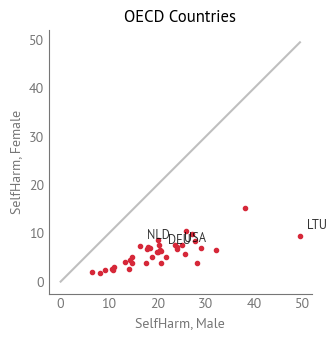

In [101]:
col = 'SelfHarmDeathRate'
self_harm_ihme = self_harm_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
self_harm_ihme_gap, self_harm_ihme_recent = summarize_gap(self_harm_ihme, col)

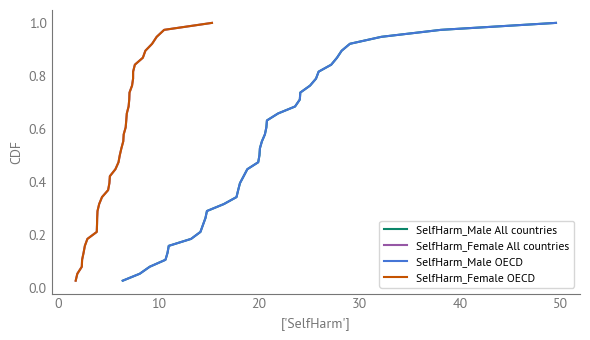

In [102]:
plot_distributions(self_harm_ihme_recent)

## Interpersonal Violence (IHME)

**Interpersonal violence (homicide) death rates (per 100,000 population)** - Deaths from interpersonal violence (homicide), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Interpersonal violence (homicide) is a significant cause of death and contributes to the HALE gender gap. Men typically have much higher homicide rates than women in most countries. This indicator provides comprehensive interpersonal violence death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO homicide rate indicator (VIOLENCE_HOMICIDERATE) which has data for 2000-2021. IHME data provides better temporal coverage (starting from 1990) and may have different methodology or data sources. Data includes separate male and female values, allowing for gender gap analysis.

In [103]:
filename_male = '../data/ihme_interpersonal_violence_deaths_male.csv'
filename_female = '../data/ihme_interpersonal_violence_deaths_female.csv'
interpersonal_violence_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='InterpersonalViolenceDeathRate',
    indicator_code='IHME_INTERPERSONAL_VIOLENCE',
    indicator_name='Interpersonal violence (homicide), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [104]:
interpersonal_violence_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,InterpersonalViolenceDeathRate,InterpersonalViolenceDeathRate_Low,InterpersonalViolenceDeathRate_High,Country
0,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2000.0,Female,1.220574,1.090956,1.357464,Australia
1,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2001.0,Female,1.155846,1.038801,1.287543,Australia
2,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2002.0,Female,1.080767,0.973158,1.215679,Australia
3,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2003.0,Female,0.889872,0.802525,1.001721,Australia
4,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2004.0,Female,0.758536,0.681027,0.855067,Australia


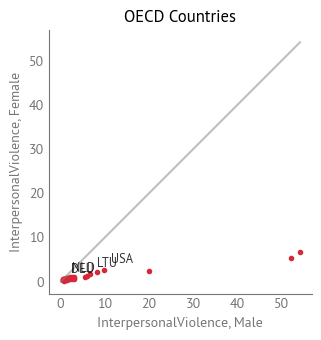

In [105]:
col = 'InterpersonalViolenceDeathRate'
interpersonal_violence_ihme = interpersonal_violence_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
interpersonal_violence_ihme_gap, interpersonal_violence_ihme_recent = summarize_gap(interpersonal_violence_ihme, col)

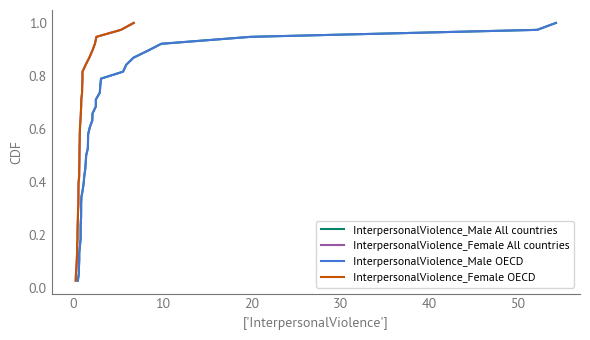

In [106]:
plot_distributions(interpersonal_violence_ihme_recent)

## Road Injuries (IHME)

**Road injuries (road traffic crash) death rates (per 100,000 population)** - Deaths from road injuries (road traffic crashes), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Road injuries (road traffic crashes) are a significant cause of death and contribute to the HALE gender gap. Men typically have 2-4 times higher road traffic death rates than women in most countries due to higher exposure to driving (including occupational exposure), occupational hazards, and potentially risk-taking behaviors. This indicator provides comprehensive road injury death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO road traffic crash death rate indicator (SA_0000001459) which only has data for 2019. IHME data provides much better temporal coverage, allowing for temporal analysis and more recent data. Data includes separate male and female values, allowing for gender gap analysis.

In [107]:
filename_male = '../data/ihme_road_injuries_deaths_male.csv'
filename_female = '../data/ihme_road_injuries_deaths_female.csv'
road_injuries_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='RoadInjuriesDeathRate',
    indicator_code='IHME_ROAD_INJURIES',
    indicator_name='Road injuries (road traffic crashes), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [108]:
road_injuries_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,RoadInjuriesDeathRate,RoadInjuriesDeathRate_Low,RoadInjuriesDeathRate_High,Country
0,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2000.0,Female,6.084094,5.568374,6.582913,Australia
1,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2001.0,Female,5.782579,5.258684,6.235018,Australia
2,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2002.0,Female,5.545272,5.058701,5.981018,Australia
3,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2003.0,Female,5.210589,4.736477,5.600680,Australia
4,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2004.0,Female,4.897544,4.475352,5.284221,Australia


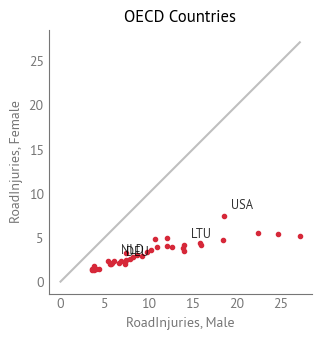

In [109]:
col = 'RoadInjuriesDeathRate'
road_injuries_ihme = road_injuries_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
road_injuries_ihme_gap, road_injuries_ihme_recent = summarize_gap(road_injuries_ihme, col)

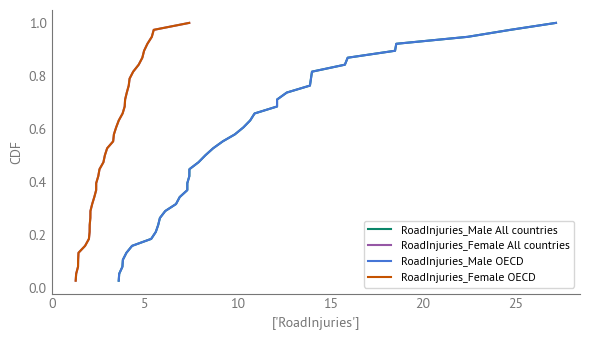

In [110]:
plot_distributions(road_injuries_ihme_recent)

## Maternal Disorders (IHME)

**Maternal disorders death rates (per 100,000 population)** - Deaths from maternal disorders, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Maternal disorders (maternal mortality) are a significant cause of death for women and can contribute to the HALE gender gap, especially in lower-income countries. High maternal mortality can significantly reduce female life expectancy, explaining why some countries have smaller gender gaps. This indicator provides comprehensive maternal disorder death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO maternal mortality ratio indicator (MDG_0000000026) which has data for 1985-2023. Note: WHO indicator uses ratio per 100,000 live births, while IHME uses rate per 100,000 population, so they measure slightly different things. IHME data may be useful for temporal analysis and provides consistent methodology with other IHME indicators. Inherently female-specific, so only female values are used in analysis.

In [111]:
filename_female = '../data/ihme_maternal_disorders_deaths_female.csv'
# Maternal disorders is female-only, so we need to handle it differently
# Load the female file and create a compatible format
maternal_disorders_ihme_female = pd.read_csv(filename_female)

# Filter to 2000-2019 (exclude 2020+ for COVID-19 reasons)
maternal_disorders_ihme_female = maternal_disorders_ihme_female.query('Year >= 2000 and Year <= 2019')

# Filter to "All ages" (if Age column exists)
if 'Age' in maternal_disorders_ihme_female.columns:
    maternal_disorders_ihme_female = maternal_disorders_ihme_female.query('Age == "All ages"')

# Map IHME country names to WHO country names
who_country_to_code = {country: code for code, country in code_to_who_country.items()}
ihme_country_name_mapping = {
    'Republic of Korea': 'South Korea',
    'United States of America': 'United States'
}
maternal_disorders_ihme_female['Location'] = maternal_disorders_ihme_female['Location'].replace(ihme_country_name_mapping)

# Convert country names to codes
maternal_disorders_ihme_female['Code'] = maternal_disorders_ihme_female['Location'].map(who_country_to_code)

# Filter out rows where country mapping failed
maternal_disorders_ihme_female = maternal_disorders_ihme_female[maternal_disorders_ihme_female['Code'].notna()].copy()

# Set Sex column to Female
maternal_disorders_ihme_female['Sex'] = 'Female'

# Rename and create columns to match WHO format
maternal_disorders_ihme_female['IndicatorCode'] = 'IHME_MATERNAL_DISORDERS'
maternal_disorders_ihme_female['IndicatorName'] = 'Maternal disorders, death rate per 100,000'
maternal_disorders_ihme_female['CountryCode'] = 'COUNTRY'
maternal_disorders_ihme_female['MaternalDisordersDeathRate'] = maternal_disorders_ihme_female['Value']
maternal_disorders_ihme_female['MaternalDisordersDeathRate_Low'] = maternal_disorders_ihme_female['Lower bound']
maternal_disorders_ihme_female['MaternalDisordersDeathRate_High'] = maternal_disorders_ihme_female['Upper bound']
maternal_disorders_ihme_female['Country'] = maternal_disorders_ihme_female['Location']

# Select and reorder columns to match WHO format
columns_to_keep = [
    'IndicatorCode', 'IndicatorName', 'Code', 'CountryCode', 'Year', 'Sex',
    'MaternalDisordersDeathRate', 'MaternalDisordersDeathRate_Low', 'MaternalDisordersDeathRate_High',
    'Country'
]
maternal_disorders_ihme = maternal_disorders_ihme_female[columns_to_keep].copy()

# Sort by country and year
maternal_disorders_ihme = maternal_disorders_ihme.sort_values(['Country', 'Year']).reset_index(drop=True)

years = maternal_disorders_ihme['Year'].unique()

print(maternal_disorders_ihme.shape)
print(f"Years: {years.min():.0f} - {years.max():.0f}")
print(f"Countries: {maternal_disorders_ihme['Country'].nunique()}")
print(f"Sex categories: {maternal_disorders_ihme['Sex'].unique()}")

(760, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female']


In [112]:
maternal_disorders_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,MaternalDisordersDeathRate,MaternalDisordersDeathRate_Low,MaternalDisordersDeathRate_High,Country
0,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2000.0,Female,0.190818,0.164745,0.219467,Australia
1,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2001.0,Female,0.167333,0.144367,0.192226,Australia
2,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2002.0,Female,0.189218,0.161726,0.215605,Australia
3,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2003.0,Female,0.124994,0.107358,0.143600,Australia
4,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2004.0,Female,0.147857,0.126645,0.171856,Australia


In [113]:
col = 'MaternalDisordersDeathRate'
maternal_disorders_ihme = maternal_disorders_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
maternal_disorders_ihme_gap, maternal_disorders_ihme_recent = summarize_gap(maternal_disorders_ihme, col, sexes=['Female'])

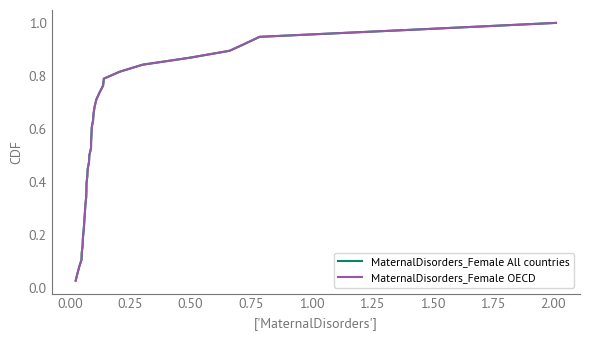

In [114]:
plot_distributions(maternal_disorders_ihme_recent)

## All-Cause Deaths Under 5 Years of Age (IHME)

**All-cause deaths under 5 years of age (per 100,000 population)** - Deaths from all causes for children under 5 years of age, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: All-cause mortality for children under 5 years of age is relevant to the HALE gender gap because HALE is calculated from birth, so early-life mortality directly affects HALE calculations. If child mortality differs by gender, it directly contributes to the HALE gender gap. Infant and child mortality is typically higher in males (biological vulnerability + some behavioral factors). This indicator provides comprehensive all-cause under-5 mortality rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is different from the WHO under-five mortality rate (U5MR, MDG_0000000007) which measures deaths per 1,000 live births. The IHME indicator measures deaths per 100,000 population, providing a complementary perspective on early-life mortality. Data includes separate male and female values, allowing for gender gap analysis.

In [115]:
filename_male = '../data/ihme_all_causes_under5_deaths_male.csv'
filename_female = '../data/ihme_all_causes_under5_deaths_female.csv'
# All-cause under 5 needs special handling because it's for "<5 years" age group, not "All ages"
# We'll create a modified version of load_ihme_indicator that filters for "<5 years" instead

def load_ihme_indicator_under5(filename_male, filename_female, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data for under-5 age group from separate male and female files.
    
    Similar to load_ihme_indicator but filters for "<5 years" age group instead of "All ages".
    """
    # Create reverse mapping from country name to code
    who_country_to_code = {country: code for code, country in code_to_who_country.items()}
    
    # Map IHME country names that differ from WHO names
    ihme_country_name_mapping = {
        'Republic of Korea': 'South Korea',
        'United States of America': 'United States'
    }
    
    def process_ihme_file(filename, sex_value):
        """Helper function to process a single IHME file."""
        df = pd.read_csv(filename)
        
        # Filter to 2000-2019 (exclude 2020+ for COVID-19 reasons)
        df = df.query('Year >= 2000 and Year <= 2019')
        
        # Filter to "<5 years" age group
        if 'Age' in df.columns:
            df = df.query('Age == "<5 years"')
        
        # Map IHME country names to WHO country names
        df['Location'] = df['Location'].replace(ihme_country_name_mapping)
        
        # Convert country names to codes
        df['Code'] = df['Location'].map(who_country_to_code)
        
        # Filter out rows where country mapping failed (not in our country list)
        df = df[df['Code'].notna()].copy()
        
        # Set Sex column to the specified value (Male or Female)
        df['Sex'] = sex_value
        
        # Rename and create columns to match WHO format
        df['IndicatorCode'] = indicator_code
        df['IndicatorName'] = indicator_name
        df['CountryCode'] = 'COUNTRY'
        df[value_col_name] = df['Value']
        df[f'{value_col_name}_Low'] = df['Lower bound']
        df[f'{value_col_name}_High'] = df['Upper bound']
        df['Country'] = df['Location']
        
        # Select and reorder columns to match WHO format
        columns_to_keep = [
            'IndicatorCode', 'IndicatorName', 'Code', 'CountryCode', 'Year', 'Sex',
            value_col_name, f'{value_col_name}_Low', f'{value_col_name}_High',
            'Country'
        ]
        df = df[columns_to_keep].copy()
        
        return df
    
    # Load and process both files
    df_male = process_ihme_file(filename_male, 'Male')
    df_female = process_ihme_file(filename_female, 'Female')
    
    # Concatenate male and female data
    df = pd.concat([df_male, df_female], ignore_index=True)
    
    # Sort by country, sex, and year
    df = df.sort_values(['Country', 'Sex', 'Year']).reset_index(drop=True)
    
    years = df['Year'].unique()
    
    print(df.shape)
    print(f"Years: {years.min():.0f} - {years.max():.0f}")
    print(f"Countries: {df['Country'].nunique()}")
    print(f"Sex categories: {df['Sex'].unique()}")
    
    return df, years

all_causes_under5_ihme, years = load_ihme_indicator_under5(
    filename_male, filename_female,
    value_col_name='AllCausesUnder5DeathRate',
    indicator_code='IHME_ALL_CAUSES_UNDER5',
    indicator_name='All-cause deaths under 5 years, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [116]:
all_causes_under5_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,AllCausesUnder5DeathRate,AllCausesUnder5DeathRate_Low,AllCausesUnder5DeathRate_High,Country
0,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2000.0,Female,108.987394,105.694199,112.339690,Australia
1,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2001.0,Female,107.017794,103.828800,110.342158,Australia
2,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2002.0,Female,105.199071,102.004207,108.668812,Australia
3,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2003.0,Female,103.204037,99.864006,106.604800,Australia
4,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2004.0,Female,102.167493,98.843241,105.603340,Australia


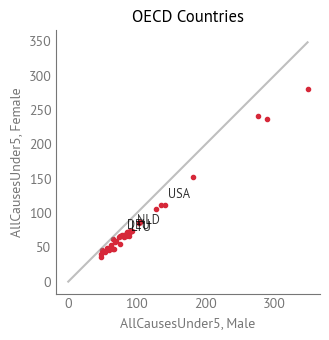

In [117]:
col = 'AllCausesUnder5DeathRate'
all_causes_under5_ihme = all_causes_under5_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
year = years[-1]
all_causes_under5_ihme_gap, all_causes_under5_ihme_recent = summarize_gap(all_causes_under5_ihme, col)

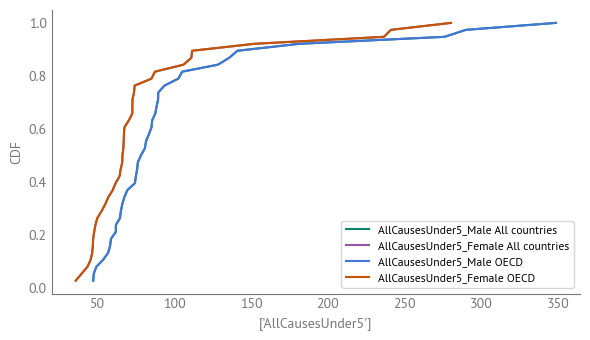

In [118]:
plot_distributions(all_causes_under5_ihme_recent)

## Phase 1: Data Preparation for Regression Analysis

### Step 1.2: Prepare Target Variables (HALE and Life Expectancy Gender Gaps)

In [119]:
# Calculate HALE gender gap from existing hale_recent DataFrame
# Gap = Female - Male (positive means females have higher HALE)
hale_recent['HALE_gap'] = hale_recent['HALE_Years_Female'] - hale_recent['HALE_Years_Male']

# Filter to OECD countries
hale_oecd = get_oecd(hale_recent)

# Display summary
hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].describe()

,HALE_Years_Male,HALE_Years_Female,HALE_gap
count,38.000000,38.000000,38.000000
mean,68.627594,70.605057,1.977462
std,2.533251,1.620032,1.601449
min,63.046587,66.927903,0.018589
25%,66.703502,69.990711,0.870341
50%,69.438269,70.730471,1.385737
75%,70.795272,71.462018,2.923884
max,72.085115,75.013962,6.062020


In [120]:
# Calculate Life Expectancy gender gap from existing le_recent DataFrame
# Gap = Female - Male (positive means females have higher Life Expectancy)
le_recent['LifeExpectancy_gap'] = le_recent['LifeExpectancy_Years_Female'] - le_recent['LifeExpectancy_Years_Male']

# Filter to OECD countries
le_oecd = get_oecd(le_recent)

# Display summary
le_oecd[['LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']].describe()

,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,LifeExpectancy_gap
count,38.000000,38.000000,38.000000
mean,78.286623,83.184132,4.897509
std,3.040136,1.914461,1.622577
min,71.050877,78.890552,2.799527
25%,76.360712,82.103078,3.625473
50%,79.469017,83.627520,4.564648
75%,80.680114,84.222983,5.589859
max,81.759398,87.152152,9.361672


In [121]:
# Diagnostic: Check Israel's (ISR) HALE values
if 'ISR' in hale_recent.index:
    isr_data = hale_recent.loc[['ISR']]
    print("=== Israel (ISR) HALE Data ===")
    print(f"Country Name: {isr_data['Country'].iloc[0]}")
    
    # Check if this is an outlier
    print(f"\nHALE Gap: {isr_data['HALE_gap'].iloc[0]:.2f} years")
    print(f"Male HALE: {isr_data['HALE_Years_Male'].iloc[0]:.2f} years")
    print(f"Female HALE: {isr_data['HALE_Years_Female'].iloc[0]:.2f} years")
    
    # Compare to other countries
    print(f"\nCountries with negative HALE gap (men > women):")
    negative_gap = hale_recent[hale_recent['HALE_gap'] < 0]
    if len(negative_gap) > 0:
        negative_gap[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].sort_values('HALE_gap')
    else:
        print("No other countries with negative gap found")
    
    # Check raw HALE data for Israel to see if there's a data issue
    print(f"\n=== Checking raw HALE data for Israel ===")
    if 'ISR' in hale.index:
        isr_raw = hale[hale['Code'] == 'ISR'].sort_values('Year')
        print(f"Years available: {sorted(isr_raw['Year'].unique())}")
        print(f"\nRaw data by year and sex:")
        isr_raw[['Year', 'Sex', 'HALE_Years']].pivot(index='Year', columns='Sex', values='HALE_Years')
    else:
        isr_data[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']]
else:
    print("Israel (ISR) not found in hale_recent")

=== Israel (ISR) HALE Data ===
Country Name: Israel

HALE Gap: 0.61 years
Male HALE: 71.17 years
Female HALE: 71.78 years

Countries with negative HALE gap (men > women):

=== Checking raw HALE data for Israel ===


### Step 1.4: Merge All Predictors into Single Dataset

In [122]:
# Start with HALE data as base (we'll add LE later)
analysis_df = hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].copy()

# Add Life Expectancy data
analysis_df = analysis_df.join(le_oecd[['LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']], how='outer')

# Merge all predictor DataFrames (already filtered to OECD in earlier sections)
# Note: We will exclude Male/Female columns, Country, and Year columns before merging
# We keep Mid (midpoint) and Gap columns as predictors instead of separate Male/Female columns
predictor_dfs = {
    'Alcohol': get_oecd(alcohol_recent),
    'ChronicRespiratory': get_oecd(chronic_respiratory_ihme_recent),
    'UnintentionalInjury': get_oecd(unintentional_injuries_ihme_recent),
    'RoadTraffic': get_oecd(traffic_recent),
    'Diabetes': get_oecd(diabetes_ihme_recent),
    'Cardiovascular': get_oecd(cardiovascular_ihme_recent),
    'Childhood': get_oecd(u5mr_recent),
    'DrugDisorder': get_oecd(drug_disorders_recent),
    'Homicide': get_oecd(homicide_recent),
    'Poisoning': get_oecd(poison_recent),
    'Suicide': get_oecd(suicide_recent),
    'MaternalMortality': get_oecd(maternal_recent),
    'Neoplasms': get_oecd(neoplasms_ihme_recent),
}

In [123]:
# Summary table of year coverage for each indicator
year_summary_df = summarize_years(predictor_dfs)
year_summary_df

,Indicator,Low_Year,High_Year,Most_Common_Year,N_Countries_Most_Common,Total_Countries
0,Alcohol,2019,2019,2019,38,38
1,ChronicRespiratory,2019,2019,2019,38,38
2,UnintentionalInjury,2019,2019,2019,38,38
3,RoadTraffic,2019,2019,2019,38,38
4,Diabetes,2019,2019,2019,38,38
5,Cardiovascular,2019,2019,2019,38,38
6,Childhood,2019,2019,2019,38,38
7,DrugDisorder,2019,2019,2019,38,38
8,Homicide,2019,2019,2019,38,38
9,Poisoning,2019,2019,2019,38,38


In [124]:
for name, df in predictor_dfs.items():
    drop_cols = ['Country', 'Year']
    # Keep Male, Female, Mid, and Gap columns for counterfactual analysis
    # Only drop Country and Year columns
    if drop_cols:
        predictor_dfs[name] = df.drop(columns=drop_cols)

# Check shapes after dropping Country and Year
for name, predictor_df in predictor_dfs.items():
    print(name, predictor_df.shape)

Alcohol (38, 4)
ChronicRespiratory (38, 4)
UnintentionalInjury (38, 4)
RoadTraffic (38, 4)
Diabetes (38, 4)
Cardiovascular (38, 4)
Childhood (38, 4)
DrugDisorder (38, 4)
Homicide (38, 4)
Poisoning (38, 4)
Suicide (38, 4)
MaternalMortality (38, 1)
Neoplasms (38, 4)


In [125]:
# Merge all predictors on index (Country codes)
for name, df in predictor_dfs.items():
    analysis_df = analysis_df.join(df, how='outer')

# Display shape and column names
analysis_df.shape

(38, 55)

In [126]:
analysis_df.head()

,HALE_Years_Male,HALE_Years_Female,HALE_gap,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,LifeExpectancy_gap,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,...,Mid_Poisoning,Suicide_Male,Suicide_Female,Gap_Suicide,Mid_Suicide,MaternalMortality_Female,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms
Code,,,,,,,,,,,,,,,,,,,,,
AUS,69.678894,70.839417,1.160523,80.720826,84.571060,3.850234,30.074132,7.174408,22.899724,18.624270,...,0.117305,19.262646,6.316721,12.945925,12.789684,5.293546,243.355910,181.856239,61.499672,212.606075
AUT,69.734435,71.097603,1.363167,79.448822,83.776301,4.327479,48.422765,10.590658,37.832107,29.506712,...,0.165058,16.571323,4.693402,11.877921,10.632362,6.606055,284.168276,237.508863,46.659413,260.838570
BEL,69.611904,70.552460,0.940556,79.502396,83.655743,4.153347,40.641776,11.033031,29.608745,25.837404,...,0.471569,20.837616,7.684374,13.153242,14.260995,4.320729,311.903927,249.263400,62.640527,280.583664
CAN,69.657904,70.912614,1.254710,80.124887,83.897128,3.772241,35.024350,8.773193,26.251157,21.898771,...,0.271167,16.488952,5.638187,10.850765,11.063569,12.266445,264.214805,225.420135,38.794670,244.817470
CHE,71.330820,71.668585,0.337766,81.759398,85.115347,3.355950,28.127289,7.215781,20.911508,17.671535,...,0.097107,13.921306,5.835274,8.086032,9.878290,5.932969,254.475067,210.169723,44.305343,232.322395


In [127]:
# Create missing data report
missing_report = pd.DataFrame({
    'Indicator': analysis_df.columns,
    'Missing_Count': [analysis_df[col].isna().sum() for col in analysis_df.columns],
    'Missing_Pct': [analysis_df[col].isna().sum() / len(analysis_df) * 100 for col in analysis_df.columns],
    'Available_Count': [analysis_df[col].notna().sum() for col in analysis_df.columns]
}).sort_values('Missing_Count', ascending=False)

missing_report

,Indicator,Missing_Count,Missing_Pct,Available_Count
0,HALE_Years_Male,0,0.0,38
41,Mid_Homicide,0,0.0,38
30,Childhood_Male,0,0.0,38
31,Childhood_Female,0,0.0,38
32,Gap_Childhood,0,0.0,38
33,Mid_Childhood,0,0.0,38
34,DrugDisorder_Male,0,0.0,38
35,DrugDisorder_Female,0,0.0,38
36,Gap_DrugDisorder,0,0.0,38
37,Mid_DrugDisorder,0,0.0,38


In [128]:
# Show which countries have complete data for all indicators
complete_cases = analysis_df.dropna()
complete_cases.shape[0], f"{complete_cases.shape[0] / len(analysis_df) * 100:.1f}% of countries have complete data"

(38, '100.0% of countries have complete data')

In [129]:
#bad = analysis_df['IPVPrevalence_Female'].isna()
#analysis_df.loc[bad].index.map(code_to_who_country)

### Step 1.5: Create Final Analysis Dataset

In [130]:
# Use complete-case analysis for primary model
analysis_complete = analysis_df.dropna()

# Document excluded countries
excluded_countries = set(analysis_df.index) - set(analysis_complete.index)
excluded_countries if excluded_countries else "No countries excluded - all OECD countries have complete data"

'No countries excluded - all OECD countries have complete data'

In [131]:
# Separate target and predictors
# Create both target variables
target_hale = analysis_complete['HALE_gap']
target_le = analysis_complete['LifeExpectancy_gap']
# Keep all predictor columns including Male, Female, Mid, and Gap for counterfactual analysis
# Only drop the target variable columns
predictors = analysis_complete.drop(columns=[
    'HALE_gap', 'HALE_Years_Male', 'HALE_Years_Female',
    'LifeExpectancy_gap', 'LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female'
])

# Display final dataset info
pd.DataFrame({
    'Dataset': ['Complete Cases'],
    'Countries': [len(analysis_complete)],
    'Target_Variables': ['HALE_gap, LifeExpectancy_gap'],
    'Number_of_Predictors': [len(predictors.columns)],
    'Predictor_Names': [', '.join(predictors.columns)]
})

,Dataset,Countries,Target_Variables,Number_of_Predictors,Predictor_Names
0,Complete Cases,38,"HALE_gap, LifeExpectancy_gap",49,"Alcohol_Male, Alcohol_Female, Gap_Alcohol, Mid..."


In [132]:
# Summary of Phase 1 completion
pd.DataFrame({
    'Step': ['1.2: Target Variable', '1.4: Merge', '1.5: Complete Cases'],
    'Status': ['Complete', 'Complete', 'Complete'],
    'Countries': [len(hale_oecd), len(analysis_df), len(analysis_complete)],
    'Variables': [3, len(analysis_df.columns), len(analysis_complete.columns)]
})

,Step,Status,Countries,Variables
0,1.2: Target Variable,Complete,38,3
1,1.4: Merge,Complete,38,55
2,1.5: Complete Cases,Complete,38,55


**Note**: Predictor standardization will be done as part of the regression pipeline (e.g., using `StandardScaler` in scikit-learn's pipeline), not as a separate preprocessing step.

## Phase 2: Exploratory Data Analysis

### Step 2.1: Descriptive Statistics

#### HALE Gender Gap (Primary Target Variable)

In [133]:
target_hale.sort_values()

Code
NLD    0.018589
SWE    0.134025
ISL    0.160198
NOR    0.238734
CHE    0.337766
IRL    0.454396
NZL    0.486508
ISR    0.610566
GBR    0.694553
DEU    0.862288
DNK    0.894501
LUX    0.914529
BEL    0.940556
ITA    1.071289
AUS    1.160523
TUR    1.169973
CAN    1.254710
GRC    1.325006
AUT    1.363167
CHL    1.408306
ESP    1.523123
USA    1.800777
FRA    1.817945
FIN    2.243172
CRI    2.258242
PRT    2.391484
COL    2.892291
SVN    2.908994
JPN    2.928847
CZE    3.091037
MEX    3.095419
KOR    3.564595
HUN    3.722175
SVK    3.930964
EST    4.790534
POL    4.929800
LVA    5.691968
LTU    6.062020
Name: HALE_gap, dtype: float64

In [134]:
# Summary statistics for target variable (HALE gap)
target_hale.describe()

count    38.000000
mean      1.977462
std       1.601449
min       0.018589
25%       0.870341
50%       1.385737
75%       2.923884
max       6.062020
Name: HALE_gap, dtype: float64

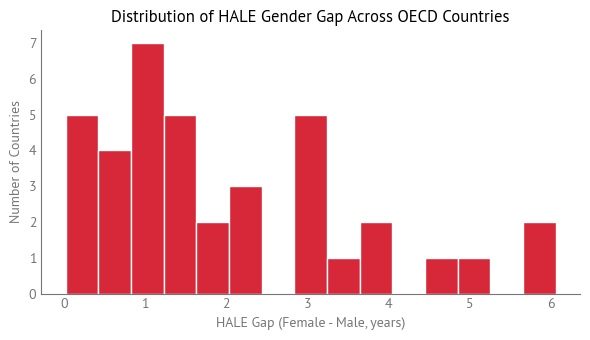

In [135]:
# Distribution of HALE gap across OECD countries
plt.hist(target_hale, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white')
decorate(xlabel='HALE Gap (Female - Male, years)', 
         ylabel='Number of Countries',
         title='Distribution of HALE Gender Gap Across OECD Countries')

In [136]:
# Identify potential outliers using IQR method
Q1 = target_hale.quantile(0.25)
Q3 = target_hale.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target_hale[(target_hale < lower_bound) | (target_hale > upper_bound)]
outliers_df = pd.DataFrame({
    'Country': outliers.index,
    'HALE_Gap': outliers.values
}).sort_values('HALE_Gap')

outliers_df if not outliers_df.empty else "No outliers detected using IQR method"

,Country,HALE_Gap
0,LTU,6.06202


#### Life Expectancy Gender Gap (Secondary Target Variable)

In [137]:
target_le.sort_values()

Code
ISL    2.799527
NLD    2.914809
NOR    3.040535
SWE    3.074617
NZL    3.271057
IRL    3.329241
CHE    3.355950
GBR    3.418288
DNK    3.573784
ISR    3.576550
CAN    3.772241
AUS    3.850234
LUX    3.917665
ITA    3.977674
BEL    4.153347
GRC    4.214505
AUT    4.327479
DEU    4.437090
USA    4.450432
CHL    4.678864
CRI    4.784602
TUR    5.036439
FIN    5.044540
ESP    5.122867
COL    5.219756
FRA    5.379232
JPN    5.449468
SVN    5.470061
CZE    5.629791
PRT    5.770625
KOR    6.006658
MEX    6.090152
HUN    6.541844
SVK    6.670498
POL    7.554684
EST    7.918789
LVA    8.919780
LTU    9.361672
Name: LifeExpectancy_gap, dtype: float64

In [138]:
# Summary statistics for target variable (Life Expectancy gap)
target_le.describe()

count    38.000000
mean      4.897509
std       1.622577
min       2.799527
25%       3.625473
50%       4.564648
75%       5.589859
max       9.361672
Name: LifeExpectancy_gap, dtype: float64

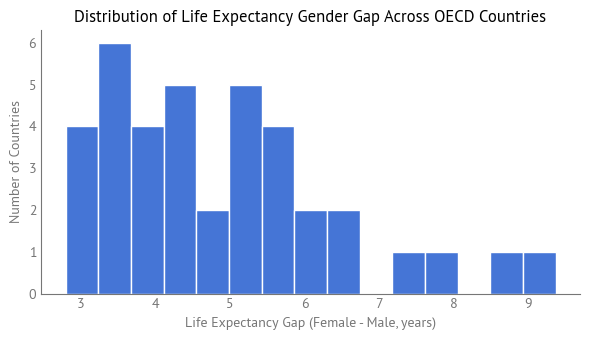

In [139]:
# Distribution of Life Expectancy gap across OECD countries
plt.hist(target_le, bins=15, color=AIBM_COLORS['blue'], edgecolor='white')
decorate(xlabel='Life Expectancy Gap (Female - Male, years)', 
         ylabel='Number of Countries',
         title='Distribution of Life Expectancy Gender Gap Across OECD Countries')

In [140]:
# Identify potential outliers using IQR method
Q1 = target_le.quantile(0.25)
Q3 = target_le.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target_le[(target_le < lower_bound) | (target_le > upper_bound)]
outliers_df = pd.DataFrame({
    'Country': outliers.index,
    'LifeExpectancy_Gap': outliers.values
}).sort_values('LifeExpectancy_Gap')

outliers_df if not outliers_df.empty else "No outliers detected using IQR method"

,Country,LifeExpectancy_Gap
1,LVA,8.919780
0,LTU,9.361672


#### Comparison of HALE and Life Expectancy Gaps

In [141]:
# Compare the two target variables
comparison_df = pd.DataFrame({
    'HALE_Gap': target_hale,
    'LifeExpectancy_Gap': target_le
})

comparison_df.describe()

,HALE_Gap,LifeExpectancy_Gap
count,38.000000,38.000000
mean,1.977462,4.897509
std,1.601449,1.622577
min,0.018589,2.799527
25%,0.870341,3.625473
50%,1.385737,4.564648
75%,2.923884,5.589859
max,6.062020,9.361672


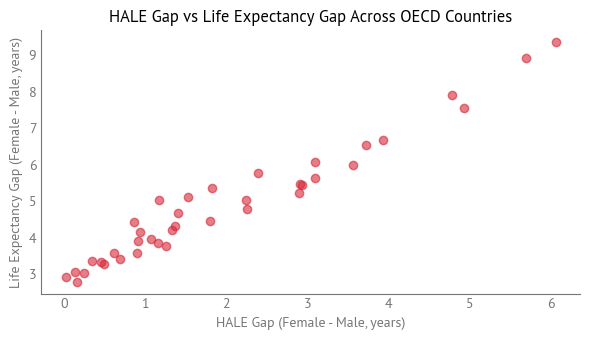

In [142]:
# Scatter plot comparing HALE gap vs Life Expectancy gap
plt.scatter(target_hale, target_le, color=AIBM_COLORS['crimson'], alpha=0.6)
decorate(xlabel='HALE Gap (Female - Male, years)', 
         ylabel='Life Expectancy Gap (Female - Male, years)',
         title='HALE Gap vs Life Expectancy Gap Across OECD Countries')

In [143]:
# Correlation between the two target variables
correlation = target_hale.corr(target_le)
print(f"Correlation between HALE gap and Life Expectancy gap: {correlation:.3f}")

Correlation between HALE gap and Life Expectancy gap: 0.975


#### Summary Statistics for Predictors

In [144]:
# Summary statistics for all predictors
predictors.describe()

,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,ChronicRespiratory_Male,ChronicRespiratory_Female,Gap_ChronicRespiratory,Mid_ChronicRespiratory,UnintentionalInjury_Male,UnintentionalInjury_Female,...,Mid_Poisoning,Suicide_Male,Suicide_Female,Gap_Suicide,Mid_Suicide,MaternalMortality_Female,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,51.670267,13.524238,38.146029,32.597252,48.772263,40.108183,8.664080,44.440223,29.711353,23.255669,...,0.358071,15.683649,4.778025,10.905624,10.230837,10.386346,278.850417,219.620779,59.229639,249.235598
std,39.794802,17.253014,24.129152,28.197382,17.638881,18.427862,10.475393,17.260494,10.754456,10.464067,...,0.318095,6.373638,2.315249,5.032198,4.081797,12.246133,85.686231,60.649677,37.200265,71.863008
min,12.860832,2.859710,9.899765,7.860271,22.799842,8.029024,-19.339710,17.076192,13.183687,6.490970,...,0.001457,5.462428,1.428371,4.034057,3.445399,1.587783,80.812106,79.756536,-0.787975,80.284321
25%,29.301366,6.499013,22.582623,17.813039,34.154103,27.123633,2.963570,32.291595,22.261761,17.432826,...,0.189255,11.922116,3.150607,7.883437,7.663104,4.289471,222.894256,187.824859,30.307345,204.624370
50%,40.036996,8.540945,28.862859,24.861359,47.819922,38.977976,8.032934,43.715973,28.634186,22.756358,...,0.278071,15.574885,4.795838,10.455254,10.255326,5.971343,293.543767,237.128380,57.601876,265.079065
75%,51.733670,11.797030,41.897523,32.296590,63.559091,50.005219,15.330862,56.534816,34.636400,27.024826,...,0.456964,19.233786,5.906438,13.101413,12.717242,11.973693,345.328231,259.834496,83.062013,308.918640
max,187.011110,80.287815,108.543518,133.286912,87.311001,89.323806,34.055132,85.409818,61.810688,50.533293,...,1.738345,37.016864,13.210332,30.859039,21.587345,66.191870,430.993162,304.741495,131.660360,365.434048


### Step 2.2: Correlation Analysis

In [145]:
# Calculate correlation matrix of all predictors
correlation_matrix = predictors.corr()

# Display correlation matrix
correlation_matrix

,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,ChronicRespiratory_Male,ChronicRespiratory_Female,Gap_ChronicRespiratory,Mid_ChronicRespiratory,UnintentionalInjury_Male,UnintentionalInjury_Female,...,Mid_Poisoning,Suicide_Male,Suicide_Female,Gap_Suicide,Mid_Suicide,MaternalMortality_Female,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms
Alcohol_Male,1.000000,0.946049,0.972791,0.995075,-0.343636,-0.505924,0.311373,-0.445655,0.722684,0.036890,...,0.749283,0.669639,0.067644,0.817024,0.541998,0.062323,0.364130,0.285325,0.373547,0.337488
Alcohol_Female,0.946049,1.000000,0.845235,0.973509,-0.304063,-0.454620,0.287754,-0.398048,0.692520,0.030110,...,0.711805,0.656356,0.114657,0.778569,0.544960,0.032096,0.327565,0.249221,0.348186,0.300453
Gap_Alcohol,0.972791,0.845235,1.000000,0.945032,-0.349325,-0.509326,0.307777,-0.450378,0.696710,0.039311,...,0.726789,0.635084,0.029578,0.790771,0.504224,0.079836,0.366321,0.292370,0.367107,0.341767
Mid_Alcohol,0.995075,0.973509,0.945032,1.000000,-0.335509,-0.496087,0.307753,-0.436251,0.721825,0.035243,...,0.746494,0.673330,0.082810,0.814720,0.549180,0.053797,0.357160,0.277584,0.370114,0.330066
ChronicRespiratory_Male,-0.343636,-0.304063,-0.349325,-0.335509,1.000000,0.832161,0.219938,0.955182,-0.097498,0.256963,...,-0.173629,-0.265241,-0.020787,-0.326383,-0.212980,-0.186741,0.402095,0.413480,0.252057,0.414201
ChronicRespiratory_Female,-0.505924,-0.454620,-0.509326,-0.496087,0.832161,1.000000,-0.357932,0.959018,-0.364406,0.159326,...,-0.324406,-0.341260,0.017016,-0.440059,-0.261609,-0.145131,0.096156,0.243618,-0.175700,0.160128
Gap_ChronicRespiratory,0.311373,0.287754,0.307777,0.307753,0.219938,-0.357932,1.000000,-0.078690,0.476876,0.152405,...,0.278317,0.153705,-0.064936,0.224555,0.101588,-0.059135,0.507911,0.267673,0.733508,0.415758
Mid_ChronicRespiratory,-0.445655,-0.398048,-0.450378,-0.436251,0.955182,0.959018,-0.078690,1.000000,-0.244344,0.216349,...,-0.261891,-0.317698,-0.001538,-0.401679,-0.248475,-0.172891,0.256784,0.341319,0.034999,0.297119
UnintentionalInjury_Male,0.722684,0.692520,0.696710,0.721825,-0.097498,-0.364406,0.476876,-0.244344,1.000000,0.612484,...,0.548348,0.666436,0.289100,0.711077,0.602303,-0.246023,0.676603,0.628581,0.533661,0.668625
UnintentionalInjury_Female,0.036890,0.030110,0.039311,0.035243,0.256963,0.159326,0.152405,0.216349,0.612484,1.000000,...,-0.098055,0.235886,0.332861,0.145622,0.278567,-0.428878,0.582528,0.659017,0.267350,0.625383


In [ ]:
# Visualize correlation matrix as heatmap
import seaborn as sns

plt.figure(figsize=(12, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
decorate(title='Correlation Matrix of Predictors (Lower Triangle)')

In [ ]:
# Identify highly correlated predictor pairs (|correlation| > 0.7)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Predictor_1': correlation_matrix.columns[i],
                'Predictor_2': correlation_matrix.columns[j],
                'Correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
high_corr_df if not high_corr_df.empty else "No highly correlated pairs (|r| > 0.7) found"

In [ ]:
# Summary of correlation analysis
pd.DataFrame({
    'Analysis': ['Total Predictors', 'High Correlations (|r| > 0.7)', 'Max Correlation', 'Min Correlation'],
    'Value': [
        len(predictors.columns),
        len(high_corr_pairs) if high_corr_pairs else 0,
        correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].max(),
        correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].min()
    ]
})

### Step 2.3: Extreme Values and Country Rankings

#### For Each Indicator: Highest and Lowest Values

In [ ]:
# Map from short indicator names to their _recent dataframe variable names
indicator_to_recent_df = {
    'Cardiovascular': 'cardiovascular_ihme_recent',
    'ChronicRespiratory': 'chronic_respiratory_ihme_recent',
    'Suicide': 'suicide_recent',
    'Alcohol': 'alcohol_recent',
    'Poisoning': 'poison_recent',
    'RoadTraffic': 'traffic_recent',
    'Homicide': 'homicide_recent',
    'MaternalMortality': 'maternal_recent',
    'Childhood': 'u5mr_recent',
    'Diabetes': 'diabetes_ihme_recent',
    'DrugDisorder': 'drug_disorders_recent',
    'UnintentionalInjury': 'unintentional_injuries_ihme_recent',
    'Neoplasms': 'neoplasms_ihme_recent',
}

# Get list of indicators from predictor_dfs
indicator_names = list(predictor_dfs.keys())

# Create tables for each indicator showing top 5 and bottom 5 countries
indicator_extremes = {}

for indicator_name in indicator_names:
    # Get the recent dataframe for this indicator
    if indicator_name in indicator_to_recent_df:
        recent_var_name = indicator_to_recent_df[indicator_name]
        if recent_var_name in globals():
            df_recent = globals()[recent_var_name]
        else:
            continue
    else:
        continue
    
    # Find Male and Female columns dynamically (they end with _Male or _Female)
    male_cols = [col for col in df_recent.columns if col.endswith('_Male')]
    female_cols = [col for col in df_recent.columns if col.endswith('_Female')]
    
    # Get the base name from the first male column (remove _Male suffix)
    if male_cols and female_cols:
        # Use the first matching pair
        male_col = male_cols[0]
        female_col = female_cols[0]
        # Verify they have the same base name
        base_name_male = male_col[:-5]  # Remove '_Male'
        base_name_female = female_col[:-7]  # Remove '_Female'
        if base_name_male == base_name_female:
            # Create summary for this indicator
            indicator_data = df_recent[[male_col, female_col]].copy()
            indicator_data['Country'] = df_recent['Country']
            
            # For male values
            male_sorted = indicator_data.sort_values(male_col, ascending=False)
            male_top5 = male_sorted.head(5)[['Country', male_col]].copy()
            male_bottom5 = male_sorted.tail(5)[['Country', male_col]].copy()
            
            # For female values
            female_sorted = indicator_data.sort_values(female_col, ascending=False)
            female_top5 = female_sorted.head(5)[['Country', female_col]].copy()
            female_bottom5 = female_sorted.tail(5)[['Country', female_col]].copy()
            
            indicator_extremes[indicator_name] = {
                'male_top5': male_top5,
                'male_bottom5': male_bottom5,
                'female_top5': female_top5,
                'female_bottom5': female_bottom5
            }

# Display results for a few key indicators
key_indicators = ['Alcohol', 'Homicide', 'Cardiovascular', 'Suicide']
for indicator in key_indicators:
    if indicator in indicator_extremes:
        print(f"\n{'='*60}")
        print(f"{indicator} - Extreme Values")
        print(f"{'='*60}")
        print(f"\nTop 5 Countries - Male Values:")
        display(indicator_extremes[indicator]['male_top5'])
        print(f"\nBottom 5 Countries - Male Values:")
        display(indicator_extremes[indicator]['male_bottom5'])
        print(f"\nTop 5 Countries - Female Values:")
        display(indicator_extremes[indicator]['female_top5'])
        print(f"\nBottom 5 Countries - Female Values:")
        display(indicator_extremes[indicator]['female_bottom5'])

#### For Gender Gaps: Largest and Smallest Gaps

In [ ]:
gap_extremes = {}

for indicator_name in indicator_names:
    if indicator_name in indicator_to_recent_df:
        recent_var_name = indicator_to_recent_df[indicator_name]
        
        # Get the recent dataframe (already filtered to OECD and most recent year)
        if recent_var_name in globals():
            df_recent = globals()[recent_var_name]
            
            # Find columns dynamically
            gap_cols = [col for col in df_recent.columns if col.startswith('Gap_')]
            male_cols = [col for col in df_recent.columns if col.endswith('_Male')]
            female_cols = [col for col in df_recent.columns if col.endswith('_Female')]
            
            # Find matching columns (same base name)
            if gap_cols and male_cols and female_cols:
                # Get the base name from the gap column (remove 'Gap_' prefix)
                gap_col = gap_cols[0]
                base_name = gap_col[4:]  # Remove 'Gap_' prefix
                
                # Find matching male and female columns
                male_col = f'{base_name}_Male'
                female_col = f'{base_name}_Female'
                
                if male_col in df_recent.columns and female_col in df_recent.columns:
                    # Create summary with country names
                    gap_data = df_recent[[male_col, female_col, gap_col]].copy()
                    gap_data['Country'] = df_recent['Country']
                    
                    # Sort by gap (largest positive gaps first)
                    # Note: Gap is computed as Male - Female, so positive means males have higher rates
                    gap_sorted = gap_data.sort_values(gap_col, ascending=False)
                    
                    gap_top5 = gap_sorted.head(5).copy()
                    gap_bottom5 = gap_sorted.tail(5).copy()
                    
                    gap_extremes[indicator_name] = {
                        'top5': gap_top5,
                        'bottom5': gap_bottom5
                    }

# Display results for key indicators
for indicator in key_indicators:
    if indicator in gap_extremes:
        print(f"\n{'='*60}")
        print(f"{indicator} - Gender Gap Extremes (Male - Female)")
        print(f"{'='*60}")
        gap_info = gap_extremes[indicator]
        # Get column names dynamically from the DataFrame
        top5_df = gap_info['top5']
        # Find Male, Female, and Gap columns
        male_col = [col for col in top5_df.columns if col.endswith('_Male')][0] if any(col.endswith('_Male') for col in top5_df.columns) else None
        female_col = [col for col in top5_df.columns if col.endswith('_Female')][0] if any(col.endswith('_Female') for col in top5_df.columns) else None
        gap_col = [col for col in top5_df.columns if col.startswith('Gap_')][0] if any(col.startswith('Gap_') for col in top5_df.columns) else None
        
        cols_to_show = ['Country']
        if male_col:
            cols_to_show.append(male_col)
        if female_col:
            cols_to_show.append(female_col)
        if gap_col:
            cols_to_show.append(gap_col)
        
        print(f"\nTop 5 Countries - Largest Gaps (Male > Female):")
        display(gap_info['top5'][cols_to_show])
        print(f"\nBottom 5 Countries - Smallest Gaps (Female > Male):")
        display(gap_info['bottom5'][cols_to_show])

#### For HALE Gap: All Countries Ranked

In [ ]:
# Create ranked table of all countries by HALE gap
hale_ranked = analysis_complete[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].copy()
hale_ranked = hale_ranked.sort_values('HALE_gap', ascending=False).reset_index()
hale_ranked['Rank'] = range(1, len(hale_ranked) + 1)
# Rename: Country (code) -> Code, add Country (name)
hale_ranked = hale_ranked.rename(columns={'Country': 'Code'})
hale_ranked['Country'] = hale_ranked['Code'].map(code_to_who_country)

# Create output version without Rank column (Rank kept internally for comparison table)
hale_ranked_output = hale_ranked[['Country', 'HALE_Years_Male', 
                                   'HALE_Years_Female', 'HALE_gap']].copy()

print("All Countries Ranked by HALE Gap (Female - Male)")
print("="*80)
hale_ranked_output

In [ ]:
# Write HALE gap by country table to HTML (without Rank column)
write_html_table(hale_ranked_output, "jb/tables/hale_gap_by_country.html")

In [ ]:
# Summary statistics for HALE gap
print("\nHALE Gap Summary Statistics:")
print("="*50)
print(f"Mean HALE Gap: {hale_ranked['HALE_gap'].mean():.2f} years")
print(f"Median HALE Gap: {hale_ranked['HALE_gap'].median():.2f} years")
print(f"Standard Deviation: {hale_ranked['HALE_gap'].std():.2f} years")
print(f"Range: {hale_ranked['HALE_gap'].min():.2f} to {hale_ranked['HALE_gap'].max():.2f} years")
print(f"\nCountries with Largest HALE Gap (Top 5):")
hale_ranked_output.head(5)
print(f"\nCountries with Smallest HALE Gap (Bottom 5):")
hale_ranked_output.tail(5)

#### For Life Expectancy Gap: All Countries Ranked

In [ ]:
# Create ranked table of all countries by Life Expectancy gap
le_ranked = analysis_complete[['LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']].copy()
le_ranked = le_ranked.sort_values('LifeExpectancy_gap', ascending=False).reset_index()
le_ranked['Rank'] = range(1, len(le_ranked) + 1)
# Rename: Country (code) -> Code, add Country (name)
le_ranked = le_ranked.rename(columns={'Country': 'Code'})
le_ranked['Country'] = le_ranked['Code'].map(code_to_who_country)

# Create output version without Rank column (Rank kept internally for comparison table)
le_ranked_output = le_ranked[['Country', 'LifeExpectancy_Years_Male', 
                              'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']].copy()

print("All Countries Ranked by Life Expectancy Gap (Female - Male)")
print("="*80)
le_ranked_output

In [ ]:
# Write Life Expectancy gap by country table to HTML (without Rank column)
write_html_table(le_ranked_output, "jb/tables/le_gap_by_country.html")

In [ ]:
# Summary statistics for Life Expectancy gap
print("\nLife Expectancy Gap Summary Statistics:")
print("="*50)
print(f"Mean Life Expectancy Gap: {le_ranked['LifeExpectancy_gap'].mean():.2f} years")
print(f"Median Life Expectancy Gap: {le_ranked['LifeExpectancy_gap'].median():.2f} years")
print(f"Standard Deviation: {le_ranked['LifeExpectancy_gap'].std():.2f} years")
print(f"Range: {le_ranked['LifeExpectancy_gap'].min():.2f} to {le_ranked['LifeExpectancy_gap'].max():.2f} years")
print(f"\nCountries with Largest Life Expectancy Gap (Top 5):")
le_ranked_output.head(5)
print(f"\nCountries with Smallest Life Expectancy Gap (Bottom 5):")
le_ranked_output.tail(5)

#### Comparison of HALE and Life Expectancy Rankings

In [ ]:
# Compare HALE and Life Expectancy rankings
comparison_ranked = pd.DataFrame({
    'Country': hale_ranked['Country'],
    'HALE_Gap': hale_ranked['HALE_gap'],
    'HALE_Rank': hale_ranked['Rank'],
    'LifeExpectancy_Gap': le_ranked['LifeExpectancy_gap'],
    'LE_Rank': le_ranked['Rank'],
}).sort_values('HALE_Gap', ascending=False)

# Create output version without rank columns
comparison_ranked_output = comparison_ranked[['Country', 'HALE_Gap', 'LifeExpectancy_Gap']].copy()

print("="*80)
print("Comparison: HALE Gap vs Life Expectancy Gap Rankings")
print("="*80)
print(f"Correlation between rankings: {comparison_ranked['HALE_Rank'].corr(comparison_ranked['LE_Rank']):.3f}")
comparison_ranked_output

In [ ]:
# Write comparison table to HTML (without rank columns)
write_html_table(comparison_ranked_output, "jb/tables/gap_comparison_by_country.html")

### Step 2.4: Summary Statistics by Indicator

In [ ]:
# Create summary table with rate and gap statistics for each indicator
def compute_indicator_stats(indicator_name, recent_var_name):
    """Compute statistics for a single indicator."""
    if recent_var_name not in globals():
        return None
    
    df_recent = globals()[recent_var_name]
    
    # Get OECD countries only for consistency
    df_oecd = get_oecd(df_recent)
    
    # Find Mid and Gap columns dynamically
    mid_cols = [col for col in df_recent.columns if col.startswith('Mid_')]
    gap_cols = [col for col in df_recent.columns if col.startswith('Gap_')]
    
    # Handle normal case: indicators with both Mid and Gap columns
    if mid_cols and gap_cols:
        mid_col = mid_cols[0]
        gap_col = gap_cols[0]
        
        # Extract midpoint and gap values
        midpoints = df_oecd[mid_col].dropna()
        gaps = df_oecd[gap_col].dropna()
        
        if len(midpoints) > 0 and len(gaps) > 0:
            return {
                'Indicator': indicator_name,
                'Median Rate': midpoints.median(),
                'Min Rate': midpoints.min(),
                'Max Rate': midpoints.max(),
                'Median Gap': gaps.median(),
                'Min Gap': gaps.min(),
                'Max Gap': gaps.max()
            }
    
    # Handle special case: MaternalMortality (female-only, no Gap/Mid columns)
    # Use the Female value as both midpoint and gap
    elif indicator_name == 'MaternalMortality':
        female_cols = [col for col in df_recent.columns if col.endswith('_Female')]
        if female_cols:
            female_col = female_cols[0]
            values = df_oecd[female_col].dropna()
            
            if len(values) > 0:
                return {
                    'Indicator': indicator_name,
                    'Median Rate': values.median(),
                    'Min Rate': values.min(),
                    'Max Rate': values.max(),
                    'Median Gap': -values.median(),
                    'Min Gap': -values.min(),
                    'Max Gap': -values.max()
                }
    
    return None

In [ ]:
# Process predictor indicators
predictor_summary = []
for indicator_name, recent_var_name in indicator_to_recent_df.items():
    stats = compute_indicator_stats(indicator_name, recent_var_name)
    if stats:
        predictor_summary.append(stats)

# Process target variables
target_summary = []
target_indicators = {
    'HALE': 'hale_recent',
    'Life Expectancy': 'le_recent'
}
for indicator_name, recent_var_name in target_indicators.items():
    stats = compute_indicator_stats(indicator_name, recent_var_name)
    if stats:
        target_summary.append(stats)

In [ ]:
# Create DataFrames (keep Indicator as a column, not index)
predictor_df = pd.DataFrame(predictor_summary)
target_df = pd.DataFrame(target_summary)

# Split predictor table into rates and gaps
predictor_rates = predictor_df[['Indicator', 'Median Rate', 'Min Rate', 'Max Rate']].copy()
predictor_gaps = predictor_df[['Indicator', 'Median Gap', 'Min Gap', 'Max Gap']].copy()

# Calculate correlations with target variables
# For rates: use Mid_ columns, for gaps: use Gap_ columns
# Special case: MaternalMortality uses Female column for both
predictor_rates['Corr HALE'] = np.nan
predictor_rates['Corr LE'] = np.nan
predictor_gaps['Corr HALE'] = np.nan
predictor_gaps['Corr LE'] = np.nan

for idx, indicator in enumerate(predictor_rates['Indicator']):
    if indicator == 'MaternalMortality':
        # MaternalMortality: use Female column for both rates and gaps
        female_col = 'MaternalMortality_Female'
        predictor_rates.loc[idx, 'Corr HALE'] = predictors[female_col].corr(target_hale)
        predictor_rates.loc[idx, 'Corr LE'] = predictors[female_col].corr(target_le)
        predictor_gaps.loc[idx, 'Corr HALE'] = predictors[female_col].corr(target_hale)
        predictor_gaps.loc[idx, 'Corr LE'] = predictors[female_col].corr(target_le)
    else:
        # Find the corresponding Mid_ and Gap_ columns in predictors DataFrame
        mid_col = f'Mid_{indicator}'
        gap_col = f'Gap_{indicator}'
        
        # Calculate correlations for rates (using Mid_ columns)
        predictor_rates.loc[idx, 'Corr HALE'] = predictors[mid_col].corr(target_hale)
        predictor_rates.loc[idx, 'Corr LE'] = predictors[mid_col].corr(target_le)
        
        # Calculate correlations for gaps (using Gap_ columns)
        predictor_gaps.loc[idx, 'Corr HALE'] = predictors[gap_col].corr(target_hale)
        predictor_gaps.loc[idx, 'Corr LE'] = predictors[gap_col].corr(target_le)

# Split target table into rates and gaps, reverse gap signs, and adjust column names
target_rates = target_df[['Indicator', 'Median Rate', 'Min Rate', 'Max Rate']].copy()
target_rates.columns = ['Indicator', 'Median', 'Min', 'Max']
target_gaps = target_df[['Indicator', 'Median Gap', 'Min Gap', 'Max Gap']].copy()
# Reverse sign of gaps (from Male - Female to Female - Male)
target_gaps['Median Gap'] = -target_gaps['Median Gap']
target_gaps['Min Gap'] = -target_gaps['Min Gap']
target_gaps['Max Gap'] = -target_gaps['Max Gap']
# After negation, min and max are swapped, so swap the column values
target_gaps['Min Gap'], target_gaps['Max Gap'] = target_gaps['Max Gap'], target_gaps['Min Gap']
target_gaps.columns = ['Indicator', 'Median Gap', 'Min Gap', 'Max Gap']

In [ ]:
print("Predictor Indicators - Rates:")
predictor_rates = predictor_rates.sort_values(by='Median Rate', ascending=False).reset_index(drop=True)
predictor_rates

In [ ]:
print("Predictor Indicators - Gaps:")
predictor_gaps = predictor_gaps.sort_values(by='Median Gap', ascending=False).reset_index(drop=True)
predictor_gaps

In [ ]:
print("Target Variables - Rates:")
target_rates.sort_values(by='Median', ascending=False).reset_index(drop=True)

In [ ]:
print("Target Variables - Gaps:")
target_gaps

In [ ]:
write_html_table(predictor_rates, "jb/tables/predictor_rates.html")
write_html_table(predictor_gaps,  "jb/tables/predictor_gaps.html")

write_html_table(target_rates,    "jb/tables/target_rates.html")
write_html_table(target_gaps,     "jb/tables/target_gaps.html")

In [ ]:
# Create table showing correlation between Rate (Mid) and Gap for each indicator
rate_gap_correlations = []

for indicator in predictor_rates['Indicator']:
    # Skip MaternalMortality - it doesn't have a Gap column (female-only)
    if indicator == 'MaternalMortality':
        continue
    
    # Find the corresponding Mid_ and Gap_ columns in predictors DataFrame
    rate_col = f'Mid_{indicator}'
    gap_col = f'Gap_{indicator}'
    
    # Calculate correlation between rate and gap
    if rate_col in predictors.columns and gap_col in predictors.columns:
        corr = predictors[rate_col].corr(predictors[gap_col])
        rate_gap_correlations.append({
            'Indicator': indicator,
            'Correlation': corr
        })

# Create DataFrame and format (keep Indicator as a column)
rate_gap_corr_df = pd.DataFrame(rate_gap_correlations)

# Sort by correlation (descending)
rate_gap_corr_df = rate_gap_corr_df.sort_values('Correlation', ascending=False).reset_index(drop=True)

In [ ]:
write_html_table(rate_gap_corr_df, "jb/tables/rate_gap_correlation.html")

In [ ]:
# Create table showing top 10 correlations between rates (Mid columns)
# Get all Mid_ columns
mid_cols = [col for col in predictors.columns if col.startswith('Mid_')]

# Calculate correlation matrix for rates
rates_corr_matrix = predictors[mid_cols].corr()

# Extract upper triangle (excluding diagonal) and convert to list of pairs
rates_corr_pairs = []
for i in range(len(rates_corr_matrix.columns)):
    for j in range(i+1, len(rates_corr_matrix.columns)):
        indicator1 = rates_corr_matrix.columns[i].replace('Mid_', '')
        indicator2 = rates_corr_matrix.columns[j].replace('Mid_', '')
        corr_val = rates_corr_matrix.iloc[i, j]
        rates_corr_pairs.append({
            'Rate 1': indicator1,
            'Rate 2': indicator2,
            'Correlation': corr_val
        })

# Create DataFrame and sort by absolute correlation
rates_corr_df = pd.DataFrame(rates_corr_pairs)
rates_corr_df['Abs Correlation'] = rates_corr_df['Correlation'].abs()
rates_corr_df = rates_corr_df.sort_values('Abs Correlation', ascending=False).head(10)

# Drop the absolute value column
rates_corr_df = rates_corr_df[['Rate 1', 'Rate 2', 'Correlation']].reset_index(drop=True)

In [ ]:
write_html_table(rates_corr_df,     "jb/tables/rate_rate_correlation_top10.html")

In [ ]:
# Create table showing top 10 correlations between gaps (Gap columns)
# Get all Gap_ columns (excluding MaternalMortality which doesn't have a Gap column)
gap_cols = [col for col in predictors.columns if col.startswith('Gap_')]

# Calculate correlation matrix for gaps
gaps_corr_matrix = predictors[gap_cols].corr()

# Extract upper triangle (excluding diagonal) and convert to list of pairs
gaps_corr_pairs = []
for i in range(len(gaps_corr_matrix.columns)):
    for j in range(i+1, len(gaps_corr_matrix.columns)):
        indicator1 = gaps_corr_matrix.columns[i].replace('Gap_', '')
        indicator2 = gaps_corr_matrix.columns[j].replace('Gap_', '')
        corr_val = gaps_corr_matrix.iloc[i, j]
        gaps_corr_pairs.append({
            'Gap 1': indicator1,
            'Gap 2': indicator2,
            'Correlation': corr_val
        })

# Create DataFrame and sort by absolute correlation
gaps_corr_df = pd.DataFrame(gaps_corr_pairs)
gaps_corr_df['Abs Correlation'] = gaps_corr_df['Correlation'].abs()
gaps_corr_df = gaps_corr_df.sort_values('Abs Correlation', ascending=False).head(10)

# Drop the absolute value column
gaps_corr_df = gaps_corr_df[['Gap 1', 'Gap 2', 'Correlation']].reset_index(drop=True)

In [ ]:
write_html_table(gaps_corr_df,     "jb/tables/gap_gap_correlation_top10.html")

### Step 2.5: Save Data for Future Use

In [ ]:
# Save predictors and target to HDF5 file for future use
import pandas as pd

# Save to HDF5 file
hdf_file = '../data/hale_analysis_data.h5'
with pd.HDFStore(hdf_file, mode='w') as store:
    store['predictors'] = predictors
    store['target_hale'] = target_hale
    store['target_le'] = target_le

In [ ]:
predictors.columns

In [ ]:
from utils import beep

beep()